# Laboratorio 6. Analisis de redes sociales en YouTube

CC3084 Data Science, Semestre II 2026

Trabajamos con dos conjuntos de datos de YouTube: uno con informacion de 293 videos y sus canales,
y otro con 406 comentarios principales publicados en una seleccion de esos videos. El objetivo es
describir la estructura de participacion de los usuarios, la relacion entre canales y temas, y el
contenido de las conversaciones observadas.

El notebook cubre los diez ejercicios del enunciado en orden: carga e integracion, calidad y
limpieza, analisis exploratorio, red bipartita autor-video, proyecciones, topologia, comunidades,
centralidad, sentimiento en espanol, y la interpretacion final con limitaciones y conclusiones.

Sobre la reproducibilidad: todo el analisis corre de arriba hacia abajo sin pasos manuales, las
semillas aleatorias estan fijadas, los recursos externos de NLTK y spaCy se descargan desde la
primera celda si hacen falta, y las dependencias estan listadas en el README del repositorio.

## 0. Entorno

Instalamos y descargamos una sola vez los recursos que no vienen con una instalacion base de
Python. Si ya estan presentes, la celda no vuelve a bajarlos.

In [1]:
import importlib
import os
import subprocess
import sys

REQUERIDOS = {
    'nltk': 'nltk',
    'emoji': 'emoji',
    'wordcloud': 'wordcloud',
    'networkx': 'networkx',
    'spacy': 'spacy',
    'pysentimiento': 'pysentimiento',
}

for modulo, paquete in REQUERIDOS.items():
    try:
        importlib.import_module(modulo)
    except ImportError:
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', paquete], check=True)

# Guardamos los corpus de NLTK dentro del proyecto. En Windows la carpeta por defecto
# puede quedar redirigida por la Microsoft Store y el lector de corpus la rechaza.
import nltk

RUTA_NLTK = os.path.abspath('.nltk_data')
os.makedirs(RUTA_NLTK, exist_ok=True)
if RUTA_NLTK not in nltk.data.path:
    nltk.data.path.insert(0, RUTA_NLTK)
if not os.path.exists(os.path.join(RUTA_NLTK, 'corpora', 'stopwords', 'spanish')):
    nltk.download('stopwords', download_dir=RUTA_NLTK, quiet=True)

import spacy

try:
    spacy.load('es_core_news_sm')
except OSError:
    subprocess.run([sys.executable, '-m', 'spacy', 'download', 'es_core_news_sm'], check=True)

# Silenciamos las barras de progreso de Hugging Face para que la salida quede legible.
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')
try:
    import datasets

    datasets.disable_progress_bars()
except Exception:
    pass

print('Entorno listo.')

Entorno listo.


In [2]:
import os
import re
import string
import warnings
from collections import Counter

import emoji
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import spacy
from nltk.corpus import stopwords
from wordcloud import WordCloud

warnings.filterwarnings('ignore')

SEMILLA = 42
np.random.seed(SEMILLA)

# Carpeta donde exportamos las tablas de nodos y aristas.
os.makedirs('salidas', exist_ok=True)

pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 150)

# Paleta unica para todo el notebook, para que las figuras se lean como un mismo sistema.
AZUL, NARANJA, VERDE, ROJO, GRIS = '#3B6FB6', '#E08A3C', '#4F9D69', '#C0504D', '#8A8F98'

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'regular',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'figure.autolayout': True,
})

print('pandas', pd.__version__, '| networkx', nx.__version__, '| numpy', np.__version__)

pandas 3.0.5 | networkx 3.6.1 | numpy 2.4.6


## 1. Carga, comprension e integracion de los datos

### 1.1 Carga de los archivos

In [3]:
videos = pd.read_csv('data/youtube_videos.csv')
comments = pd.read_csv('data/youtube_comments.csv')

print('videos:', videos.shape)
print('comentarios:', comments.shape)

videos: (293, 20)
comentarios: (406, 17)


### 1.2 Unidad de observacion, llave primaria y variables relevantes

En youtube_videos.csv cada fila es un video y la llave primaria es video_id. El archivo tambien
trae channel_id, que es el identificador estable del canal, a diferencia de channel_name, que
puede repetirse o cambiar con el tiempo. Las variables relevantes para este trabajo son video_id,
channel_id, title, category, source_query, source_group, view_count y publish_date.

En youtube_comments.csv cada fila es un comentario principal, sin respuestas anidadas, y la llave
primaria es comment_id. La llave foranea hacia el otro archivo es video_id. El identificador del
autor del comentario es author_channel_id, que es distinto del channel_id del video: uno es quien
comenta y el otro es quien publico el video. Las variables relevantes son comment_id, video_id,
author_channel_id, text, like_count_text y reply_count.

In [4]:
print('video_id unicos en videos:', videos['video_id'].nunique(), 'de', len(videos), 'filas')
print('comment_id unicos en comentarios:', comments['comment_id'].nunique(), 'de', len(comments), 'filas')
print()
print('Tipos de las variables relevantes de videos:')
print(videos[['video_id', 'channel_id', 'title', 'category', 'source_group', 'view_count', 'publish_date']].dtypes)
print()
print('Tipos de las variables relevantes de comentarios:')
print(comments[['comment_id', 'video_id', 'author_channel_id', 'text', 'like_count_text', 'reply_count']].dtypes)

video_id unicos en videos: 293 de 293 filas
comment_id unicos en comentarios: 406 de 406 filas

Tipos de las variables relevantes de videos:
video_id          str
channel_id        str
title             str
category          str
source_group      str
view_count      int64
publish_date      str
dtype: object

Tipos de las variables relevantes de comentarios:
comment_id             str
video_id               str
author_channel_id      str
text                   str
like_count_text        str
reply_count          int64
dtype: object


### 1.3 Relacion entre canal, video, autor, comentario, categoria y consulta

Un canal identificado por channel_id publica uno o varios videos, y cada video pertenece a un solo
canal. Cada video tiene una category asignada por YouTube y entro al conjunto de datos a traves de
una o varias consultas de busqueda registradas en source_query y query_hits, agrupadas en
source_group segun la estrategia de recoleccion.

Un comentario pertenece a un solo video y fue escrito por un autor identificado con
author_channel_id, que no tiene relacion necesaria con el canal que publico el video. Un mismo
autor puede comentar en varios videos, y eso es exactamente lo que permite armar la red autor-video
de la seccion 4: autor y video son los dos tipos de nodo, y el acto de comentar es lo que los
conecta. La categoria y la consulta de busqueda son atributos del video, nunca relaciones entre
personas, asi que las usamos como atributos de nodo y no como aristas.

In [5]:
print('Canales distintos que publicaron videos:', videos['channel_id'].nunique())
print('Autores distintos que comentaron:', comments['author_channel_id'].nunique())
print('Canales que recibieron al menos un comentario:', comments['channel_id'].nunique())
print()
print('Videos por estrategia de recoleccion:')
print(videos['source_group'].value_counts())

Canales distintos que publicaron videos: 97
Autores distintos que comentaron: 332
Canales que recibieron al menos un comentario: 8

Videos por estrategia de recoleccion:
source_group
topic           177
official_gov    105
channel          11
Name: count, dtype: int64


### 1.4 Integracion por video_id

In [6]:
comments_full = comments.merge(
    videos,
    on='video_id',
    how='left',
    suffixes=('_comentario', '_video'),
    indicator=True,
)

print(comments_full['_merge'].value_counts())
print()
emparejados = int((comments_full['_merge'] == 'both').sum())
print(f'{emparejados} de {len(comments)} comentarios se asociaron con un video, '
      f'{emparejados / len(comments):.1%} del total.')

_merge
both          406
left_only       0
right_only      0
Name: count, dtype: int64

406 de 406 comentarios se asociaron con un video, 100.0% del total.


In [7]:
videos_con_comentarios = comments['video_id'].nunique()

print(f'Videos con al menos un comentario: {videos_con_comentarios} de {len(videos)}.')
print(f'Cobertura: {videos_con_comentarios / len(videos):.1%} de los videos del conjunto tiene comentarios.')

Videos con al menos un comentario: 19 de 293.
Cobertura: 6.5% de los videos del conjunto tiene comentarios.


Los 406 comentarios se asociaron con un video, lo cual era esperable porque el archivo de
comentarios se construyo a partir de los videos del otro archivo. El hallazgo importante esta del
otro lado del emparejamiento: los comentarios se reparten en apenas 19 de los 293 videos.

Esta es la limitacion mas fuerte de todo el laboratorio y la retomamos varias veces. La red
autor-video de la seccion 4 solo puede contener informacion de esos 19 videos. No sabemos si los
otros 274 videos realmente no tienen comentarios en YouTube o si simplemente no se recolectaron,
de modo que la ausencia de aristas no es evidencia de ausencia de conversacion.

## 2. Calidad, limpieza y preprocesamiento

### 2.1 Diagnostico inicial de calidad

Revisamos dimensiones, tipos, faltantes, duplicados, variables constantes, valores atipicos y la
consistencia entre identificadores, nombres visibles y handles.

In [8]:
def diagnostico(df, nombre):
    print(f'===== {nombre} =====')
    print('Dimensiones:', df.shape)
    print()
    resumen = pd.DataFrame({
        'tipo': df.dtypes.astype(str),
        'nulos': df.isna().sum(),
        'pct_nulos': (df.isna().mean() * 100).round(1),
        'unicos': df.nunique(dropna=True),
    })
    resumen['constante'] = resumen['unicos'] <= 1
    print(resumen.to_string())
    print()
    print('Filas duplicadas completas:', int(df.duplicated().sum()))
    print()


diagnostico(videos, 'videos')
diagnostico(comments, 'comentarios')

===== videos =====
Dimensiones: (293, 20)

                      tipo  nulos  pct_nulos  unicos  constante
video_id               str      0        0.0     293      False
title                  str      0        0.0     274      False
channel_name           str      0        0.0      97      False
channel_id             str      0        0.0      97      False
source_query           str      0        0.0      21      False
source_group           str      0        0.0       3      False
dataset_sources        str      0        0.0      23      False
channel_handle         str      0        0.0      97      False
published_time         str     13        4.4      80      False
view_count_text        str     13        4.4     259      False
description_snippet    str     25        8.5     236      False
video_url              str      0        0.0     293      False
query_hits             str      0        0.0      26      False
keywords               str      0        0.0     106      Fal

In [9]:
print('Duplicados en las llaves primarias')
print('  video_id duplicados:', int(videos['video_id'].duplicated().sum()))
print('  comment_id duplicados:', int(comments['comment_id'].duplicated().sum()))
print()

print('Variables constantes o vacias')
print('  valores unicos de is_pinned:', comments['is_pinned'].unique().tolist())
print('  valores no nulos de viewer_rating:', int(comments['viewer_rating'].notna().sum()), 'de', len(comments))
print('  upload_date igual a publish_date:', f"{(videos['upload_date'] == videos['publish_date']).mean():.1%}")
print('  owner_handle igual a channel_handle:', f"{(videos['owner_handle'] == videos['channel_handle']).mean():.1%}")

Duplicados en las llaves primarias
  video_id duplicados: 0
  comment_id duplicados: 0

Variables constantes o vacias
  valores unicos de is_pinned: [False]
  valores no nulos de viewer_rating: 0 de 406
  upload_date igual a publish_date: 100.0%
  owner_handle igual a channel_handle: 100.0%


In [10]:
def atipicos_iqr(serie, nombre):
    serie = pd.to_numeric(serie, errors='coerce').dropna()
    q1, q3 = serie.quantile([0.25, 0.75])
    rango = q3 - q1
    limite = q3 + 1.5 * rango
    fuera = serie[serie > limite]
    print(f'{nombre}: mediana {serie.median():,.0f} | p75 {q3:,.0f} | maximo {serie.max():,.0f} | '
          f'sobre el limite superior {len(fuera)} registros')


print('Deteccion de valores atipicos por rango intercuartil')
atipicos_iqr(videos['view_count'], 'view_count')
atipicos_iqr(comments['reply_count'], 'reply_count')
print()
print('Videos con mas vistas:')
print(videos.nlargest(5, 'view_count')[['channel_name', 'title', 'view_count']].to_string(index=False, max_colwidth=45))

Deteccion de valores atipicos por rango intercuartil
view_count: mediana 1,175 | p75 7,465 | maximo 8,190,449 | sobre el limite superior 49 registros
reply_count: mediana 0 | p75 0 | maximo 7 | sobre el limite superior 30 registros

Videos con mas vistas:
    channel_name                                         title  view_count
Luisito Comunica Los ALUCINANTES autobuses de Guatemala | "...     8190449
      De todo Gt 🚫LOS FAMOSOS BUSES ESMERALDA los mas RÁPID...     3152619
El Mapa de Sebas 🇬🇹HISTORIA de GUATEMALA en 17 minutos🇬🇹 - ...      749356
      De todo Gt   Este BUS me LLEVO a UN PARAISO EN GUATEMALA      504374
      De todo Gt ✅ ASÍ es una EXHIBICION DE BUSES EN GUATEMALA      424874


In [11]:
nombres_por_canal = videos.groupby('channel_id')['channel_name'].nunique()
handles_por_canal = videos.groupby('channel_id')['channel_handle'].nunique()
nombres_por_autor = comments.groupby('author_channel_id')['author_name'].nunique()
handles_por_autor = comments.groupby('author_channel_id')['author_handle'].nunique()

print('Consistencia entre identificadores, nombres y handles')
print('  canales con mas de un channel_name:', int((nombres_por_canal > 1).sum()))
print('  canales con mas de un channel_handle:', int((handles_por_canal > 1).sum()))
print('  autores con mas de un author_name:', int((nombres_por_autor > 1).sum()))
print('  autores con mas de un author_handle:', int((handles_por_autor > 1).sum()))
print()

canales_por_nombre = videos.groupby('channel_name')['channel_id'].nunique()
print('  nombres de canal usados por mas de un channel_id:', int((canales_por_nombre > 1).sum()))

Consistencia entre identificadores, nombres y handles
  canales con mas de un channel_name: 0
  canales con mas de un channel_handle: 0
  autores con mas de un author_name: 0
  autores con mas de un author_handle: 0

  nombres de canal usados por mas de un channel_id: 0


Los dos archivos estan limpios en lo estructural: no hay filas duplicadas completas, no hay
llaves primarias repetidas y el emparejamiento por video_id es total. Los problemas que si
encontramos son de contenido.

La variable is_pinned llega siempre en False para los 406 comentarios y viewer_rating esta vacia
en el 100 por ciento de los registros, asi que ninguna de las dos aporta variabilidad.
De la misma forma, upload_date reproduce exactamente publish_date y owner_handle reproduce
channel_handle, o sea que son columnas redundantes.

En cuanto a valores atipicos, view_count tiene una cola derecha extrema: la mediana esta cerca de
las 1,200 vistas y el video mas visto supera los ocho millones, cuatro ordenes de magnitud por
encima. Esto no es un error de captura sino la forma tipica de la distribucion de popularidad en
YouTube, asi que no eliminamos esos registros. Lo que si hacemos es usar escala logaritmica al graficarlos y correlaciones de
rango al compararlos, para que un solo video no domine el resultado.

La consistencia entre identificadores y nombres visibles es perfecta en ambos sentidos: cada
channel_id tiene un unico channel_name y un unico channel_handle, y cada author_channel_id tiene
un unico author_name y un unico author_handle. Aun asi seguimos usando los identificadores como
llaves, porque los nombres visibles pueden cambiar en cualquier momento en la plataforma y el
identificador no.

### 2.2 Variables que no podemos usar o que requieren precauciones

viewer_rating esta vacia en los 406 registros, asi que la descartamos por completo.

is_pinned es constante en False, no aporta variabilidad y la descartamos del analisis, aunque la
dejamos en el archivo original por transparencia.

published_time en videos y published_text en comentarios son tiempos relativos del estilo hace 2
dias o hace 3 meses, que dependen del momento exacto de la recoleccion y no son fechas. Para
videos tenemos publish_date en formato ISO y usamos esa. Para comentarios no existe una fecha
exacta equivalente, de modo que cualquier analisis temporal de comentarios queda limitado a esas
categorias relativas y no lo usamos para ordenar eventos.

reply_count es la variable mas delicada de todo el conjunto. Dice cuantas respuestas recibio un
comentario, pero no dice quien las escribio ni contiene su texto. Por eso nunca la convertimos en
una arista entre usuarios: la usamos solo como atributo descriptivo de intensidad de un comentario.

view_count_text y like_count_text vienen como texto con formato de la interfaz de YouTube y hay
que convertirlas antes de calcular. Lo hacemos en el punto 2.4.

dataset_sources describe de que archivo de recoleccion vino cada registro. Sirve para auditoria
pero no es una variable analitica.

description_snippet es un fragmento recortado de description, asi que lo tratamos como redundante
y preferimos description completa cuando se necesita texto del video.

video_title en el archivo de comentarios tambien es redundante porque se recupera con el
emparejamiento por video_id.

upload_date y owner_handle son copias exactas de publish_date y channel_handle, no las usamos.

Finalmente, source_query y source_group describen como se encontro el video durante la
recoleccion, no el tema definitivo del video. Los usamos para explicar el sesgo del muestreo,
nunca como una etiqueta tematica confiable.

### 2.3 Normalizacion de identificadores y nombres

No sustituimos identificadores por nombres visibles en ningun momento: channel_id, video_id,
comment_id y author_channel_id siguen siendo las llaves de todo el analisis. Lo unico que hacemos
aqui es garantizar que los identificadores sean texto sin espacios sobrantes y que los nombres
visibles queden recortados, para que no aparezcan etiquetas duplicadas solo por diferencias de
espaciado.

In [12]:
ids_videos = ['video_id', 'channel_id']
ids_comments = ['comment_id', 'video_id', 'channel_id', 'author_channel_id']
nombres_videos = ['channel_name', 'channel_handle', 'title']
nombres_comments = ['author_name', 'author_handle']

for col in ids_videos + nombres_videos:
    videos[col] = videos[col].astype(str).str.strip()

for col in ids_comments + nombres_comments:
    comments[col] = comments[col].astype(str).str.strip()

# Verificamos que la normalizacion no haya fusionado ni roto ninguna llave.
print('video_id unicos tras normalizar:', videos['video_id'].nunique(), 'de', len(videos))
print('comment_id unicos tras normalizar:', comments['comment_id'].nunique(), 'de', len(comments))
print('author_channel_id unicos tras normalizar:', comments['author_channel_id'].nunique())

video_id unicos tras normalizar: 293 de 293
comment_id unicos tras normalizar: 406 de 406
author_channel_id unicos tras normalizar: 332


### 2.4 Conversion de las variables de conteo almacenadas como texto

view_count_text viene con el formato que muestra la interfaz, por ejemplo 2,390 vistas, y tiene 13
valores nulos. like_count_text viene como numero en texto y usa un espacio en blanco cuando el
comentario no tiene me gusta visibles.

La funcion de conversion trata estos casos: quita las palabras vistas y visitas, elimina la coma
como separador de miles, interpreta los sufijos abreviados mil, K y M multiplicando por mil o por
un millon, convierte el espacio en blanco y la cadena vacia en cero porque en la interfaz eso
significa ausencia de me gusta, y devuelve un valor faltante cuando el texto no se puede
interpretar en vez de inventar un cero.

Para validar la funcion la aplicamos sobre view_count_text y comparamos contra view_count, que ya
viene numerico en el archivo.

In [13]:
SUFIJOS = {'mil': 1_000, 'k': 1_000, 'm': 1_000_000}


def texto_a_numero(valor):
    """Convierte un conteo en texto de YouTube a entero. Devuelve NaN si no se puede interpretar."""
    if pd.isna(valor):
        return np.nan

    texto = str(valor).strip().lower()
    if texto in {'', 'nan', 'none'}:
        return 0

    for palabra in ['vistas', 'visitas', 'views', 'me gusta', 'likes']:
        texto = texto.replace(palabra, '')
    texto = texto.replace(',', '').replace('\xa0', '').strip()

    multiplicador = 1
    for sufijo, factor in SUFIJOS.items():
        if texto.endswith(sufijo):
            multiplicador = factor
            texto = texto[: -len(sufijo)].strip()
            break

    texto = texto.replace(' ', '')
    try:
        return int(float(texto) * multiplicador)
    except ValueError:
        return np.nan


pruebas = ['2,390 vistas', '4 vistas', '1.2 mil vistas', '3.4M', ' ', '', None, 'sin datos']
for entrada in pruebas:
    print(f'  {str(entrada)!r:>16} -> {texto_a_numero(entrada)}')

    '2,390 vistas' -> 2390
        '4 vistas' -> 4
  '1.2 mil vistas' -> 1200
            '3.4M' -> 3400000
               ' ' -> 0
                '' -> 0
            'None' -> nan
       'sin datos' -> nan


In [14]:
videos['view_count_calculado'] = videos['view_count_text'].apply(texto_a_numero)
con_texto = videos['view_count_text'].notna()

coinciden = int((videos.loc[con_texto, 'view_count_calculado'] == videos.loc[con_texto, 'view_count']).sum())
print(f'Nuestro calculo coincide con view_count en {coinciden} de {int(con_texto.sum())} videos con texto disponible.')

diferencias = (videos.loc[con_texto, 'view_count'] - videos.loc[con_texto, 'view_count_calculado']).abs()
diferencias = diferencias[diferencias > 0]
print(f'En los {len(diferencias)} que no coinciden la diferencia mediana es de {diferencias.median():.0f} vistas '
      f'y la maxima de {diferencias.max():.0f}.')
print()

comments['like_count'] = comments['like_count_text'].apply(texto_a_numero)
print('like_count generado a partir de texto:')
print(comments['like_count'].describe().round(2).to_string())
print()
print('valores invalidos que quedaron como faltantes:', int(comments['like_count'].isna().sum()))

Nuestro calculo coincide con view_count en 227 de 280 videos con texto disponible.
En los 53 que no coinciden la diferencia mediana es de 4 vistas y la maxima de 3382.

like_count generado a partir de texto:
count    406.00
mean       5.73
std       30.66
min        0.00
25%        0.00
50%        1.00
75%        2.00
max      405.00

valores invalidos que quedaron como faltantes: 0


La conversion reproduce view_count en 227 de los 280 videos que traen texto. En los 53 restantes la
diferencia mediana es de solo 4 vistas, aunque en el video mas visto de ese grupo llega a 3,382. Eso
es consistente con que view_count y view_count_text se hayan capturado en momentos ligeramente
distintos mientras el contador de YouTube seguia subiendo, y con que la diferencia crezca en
proporcion al trafico del video. No es un error de la funcion. Los 13 videos sin view_count_text
quedan cubiertos porque view_count si esta completo.

Con la funcion validada generamos like_count, que no venia precalculado, y no queda ningun valor
invalido. De aqui en adelante usamos view_count y like_count numericos para todo calculo
cuantitativo, tal como recomienda el enunciado.

### 2.5 y 2.6 Texto original y texto limpio

Conservamos el comentario tal como fue publicado en la columna texto_original. Lo necesitamos
intacto por dos razones: para auditar cualquier resultado contra la fuente, y porque el modelo de
sentimiento de la seccion 9 fue entrenado con texto de redes sociales y aprovecha las mayusculas,
los signos de puntuacion y los emojis que una limpieza agresiva destruiria.

En paralelo construimos texto_limpio para el analisis de frecuencias, bigramas y nube de palabras.
Las decisiones fueron estas.

Minusculas. Convertimos todo a minusculas para que Pueblo y pueblo cuenten como la misma palabra.

URL. Las eliminamos, porque una direccion web no es vocabulario del comentario y suele repetirse
identica en varios mensajes.

Hashtags. Los extraemos a una columna propia y ademas conservamos la palabra sin el simbolo dentro
del texto limpio, porque en un hashtag la palabra si es contenido tematico.

Menciones. Las extraemos a una columna propia y las quitamos del texto limpio. A diferencia del
hashtag, una mencion es un identificador de cuenta y no vocabulario.

Puntuacion y numeros. Los eliminamos. Ningun analisis de frecuencia que hacemos depende de ellos y
en cambio generan tokens sueltos.

Emojis. Esta fue la decision que mas nos costo. La opcion inicial era traducirlos a su descripcion
en texto, pero eso inyecta palabras que el usuario nunca escribio: un solo emoji de risa se
convierte en tres tokens de la tabla de palabras frecuentes y contamina el conteo. La solucion que
adoptamos es separar los dos canales. Los emojis salen del texto limpio y se guardan completos en
una columna propia, donde los analizamos aparte en el punto 3.1 con su propia tabla de frecuencia.
Asi no perdemos la senal de tono y tampoco ensuciamos el vocabulario.

Emojis ya convertidos a texto en la fuente. Al revisar los bigramas detectamos que dos comentarios
del archivo original traen emojis guardados como codigos entre dos puntos, del estilo
:hand-purple-blue-peace:. Son pocos, cuatro apariciones, pero se colaban en la tabla de bigramas
mas frecuentes como si fueran palabras en ingles. Los detectamos con una expresion regular, los
contamos junto a los demas emojis y los sacamos del texto limpio.

Stopwords. Usamos la lista de espanol de NLTK junto con la de spaCy, mas un conjunto pequeno de
muletillas de internet como jaja y jeje. Tambien descartamos tokens de dos caracteres o menos.

Lematizacion. Usamos el modelo es_core_news_sm de spaCy para reducir cada palabra a su lema. La
alternativa era el stemmer de Snowball, que es mas rapido pero corta las palabras en raices como
diput o corrupt, imposibles de leer en una grafica y con riesgo de fusionar terminos distintos. El
lematizador devuelve diputado y corrupto, que son palabras reales y hacen los resultados
interpretables sin costo apreciable de tiempo en 406 comentarios.

In [15]:
nlp = spacy.load('es_core_news_sm', disable=['ner', 'parser'])

MULETILLAS = {'jaja', 'jajaja', 'jajajaja', 'jeje', 'jejeje', 'jaj', 'jsjs', 'xd', 'aja'}
STOPWORDS_ES = set(stopwords.words('spanish')) | set(nlp.Defaults.stop_words) | MULETILLAS

patron_url = re.compile(r'https?://\S+|www\.\S+')
patron_hashtag = re.compile(r'#(\w+)')
patron_mencion = re.compile(r'@[\w.\-]+')
# Algunos comentarios traen el emoji ya convertido a texto por la herramienta de recoleccion.
patron_emoji_texto = re.compile(r':[a-zA-Z0-9_\-]{2,}:')
SIGNOS = string.punctuation + '¿¡«»“”„‘’…—–·´`^~'
tabla_puntuacion = str.maketrans(SIGNOS, ' ' * len(SIGNOS))

print('Stopwords en espanol utilizadas:', len(STOPWORDS_ES))

Stopwords en espanol utilizadas:

 678


In [16]:
def normalizar(texto):
    """Deja el comentario en minusculas, sin URL, menciones, emojis, puntuacion ni numeros.

    Los hashtags conservan su palabra porque son contenido tematico.
    """
    texto = patron_url.sub(' ', str(texto))
    texto = patron_mencion.sub(' ', texto)
    texto = patron_hashtag.sub(r' \1 ', texto)
    texto = emoji.replace_emoji(texto, ' ')
    texto = patron_emoji_texto.sub(' ', texto)
    texto = texto.lower()
    texto = texto.translate(tabla_puntuacion)
    texto = re.sub(r'\d+', ' ', texto)
    return re.sub(r'\s+', ' ', texto).strip()


comments['texto_original'] = comments['text'].astype(str)
comments['emojis'] = comments['texto_original'].apply(
    lambda t: [d['emoji'] for d in emoji.emoji_list(t)] + patron_emoji_texto.findall(t)
)
comments['hashtags'] = comments['texto_original'].apply(patron_hashtag.findall)
comments['menciones'] = comments['texto_original'].apply(patron_mencion.findall)
comments['texto_normalizado'] = comments['texto_original'].apply(normalizar)

# Lematizacion por lotes con spaCy, mucho mas rapido que documento por documento.
tokens_limpios = []
for doc in nlp.pipe(comments['texto_normalizado'].tolist(), batch_size=64):
    tokens_limpios.append([
        token.lemma_.lower() for token in doc
        if token.is_alpha and len(token.lemma_) > 2 and token.lemma_.lower() not in STOPWORDS_ES
    ])

comments['tokens'] = tokens_limpios
comments['texto_limpio'] = [' '.join(t) for t in tokens_limpios]

comments[['texto_original', 'texto_limpio']].head(8)

,texto_original,texto_limpio
0,Ese corrupto amigo de la vieja fiscal los teng...,corrupto amigo viejo fiscal verbo él carcel
1,"Están jóvenes porque no buscan un trabajo, tu...",joven buscar trabajo suerte policía gustar var...
2,Me dejaron con ganas de demandar la ilegalidad...,dejar gana demandar ilegalidad reunión virtual...
3,Veremos a este mafioso de Mazariegos en la cár...,mafioso mazariego cárcel tiempo sombra
4,eso es para que salga de USA por su propio pie...,salir pie auto deportar
5,Imagine if they had to walk back home.,imagine they had walk back home
6,buenísima investigacion :hand-purple-blue-peac...,buenísima investigacion
7,"Lleven su lonchera, sacrifiquense un poco. Y r...",lonchera sacrifiquensar reintevren dinero robar


### 2.7 Efecto cuantificado de la limpieza

In [17]:
vacios_antes = int((comments['texto_original'].str.strip() == '').sum())
vacios_despues = int((comments['texto_limpio'].str.strip() == '').sum())

dup_antes = int(comments['texto_original'].str.strip().str.lower().duplicated().sum())
dup_despues = int(comments['texto_limpio'].duplicated().sum())

caracteres_antes = comments['texto_original'].str.len()
caracteres_despues = comments['texto_limpio'].str.len()
palabras_antes = comments['texto_normalizado'].str.split().apply(len)
palabras_despues = comments['tokens'].apply(len)

resumen_limpieza = pd.DataFrame({
    'antes': [len(comments), vacios_antes, dup_antes, round(caracteres_antes.mean(), 1),
              int(palabras_antes.sum())],
    'despues': [len(comments), vacios_despues, dup_despues, round(caracteres_despues.mean(), 1),
                int(palabras_despues.sum())],
}, index=['registros', 'textos vacios', 'textos duplicados', 'caracteres promedio', 'palabras totales'])

print(resumen_limpieza.to_string())
print()
modificados = int((comments['texto_original'].str.strip().str.lower() != comments['texto_limpio']).sum())
print(f'Registros eliminados: 0. Ningun comentario se borra, la limpieza solo agrega columnas.')
print(f'Registros cuyo texto cambio con la limpieza: {modificados} de {len(comments)}.')
print(f'Vocabulario distinto tras la limpieza: {len(set(t for lista in comments["tokens"] for t in lista))} lemas.')

                      antes  despues
registros             406.0    406.0
textos vacios           0.0     10.0
textos duplicados       3.0     14.0
caracteres promedio   139.5     74.9
palabras totales     9703.0   3931.0

Registros eliminados: 0. Ningun comentario se borra, la limpieza solo agrega columnas.
Registros cuyo texto cambio con la limpieza: 397 de 406.
Vocabulario distinto tras la limpieza: 1906 lemas.


In [18]:
print('Comentarios que quedaron sin ningun token, con su texto original:')
print(comments.loc[comments['texto_limpio'] == '', 'texto_original'].head(10).to_string())

Comentarios que quedaron sin ningun token, con su texto original:
38                                      😮
49                                     ❤🎉
97                                   que?
112                               Cierto.
129                                    😂😂
139              ​ @Murmullodelbarrio 👍🇬🇹
187                                👏👏👏👏👏👏
272                               Cierto.
318    Ud y quienes mas😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂😂
388                          Primero Dios


No eliminamos ningun registro: la limpieza agrega columnas y deja intacto el original, de modo que
los 406 comentarios siguen disponibles para el analisis de sentimiento. El costo esta en el
vocabulario, que se reduce a menos de la mitad de las palabras iniciales despues de quitar
stopwords, puntuacion, numeros y emojis.

Aparecen comentarios vacios despues de limpiar que no lo estaban antes. Al revisarlos se entiende
por que: son mensajes formados solo por emojis, por risas escritas o por una sola palabra vacia de
contenido. Lo mismo explica el aumento de duplicados, porque dos comentarios distintos que solo
decian gracias terminan con el mismo texto limpio.

La consecuencia metodologica es concreta y la respetamos en todo el notebook: un texto_limpio vacio
no significa un comentario vacio. Por eso las frecuencias de palabras se calculan sobre los
comentarios que si dejaron tokens, mientras que el analisis de sentimiento de la seccion 9 corre
sobre texto_original y conserva los 406 registros.

## 3. Analisis exploratorio

### 3.1 Descripcion general

Empezamos por los conteos basicos de las cuatro entidades del problema: videos, canales,
comentarios y autores.

In [19]:
resumen_global = pd.Series({
    'videos': len(videos),
    'canales que publicaron': videos['channel_id'].nunique(),
    'videos con comentarios': comments['video_id'].nunique(),
    'canales con comentarios': comments['channel_id'].nunique(),
    'comentarios': len(comments),
    'autores distintos': comments['author_channel_id'].nunique(),
}, name='conteo')

print(resumen_global.to_string())
print()
print('Comentarios por autor:')
print(comments.groupby('author_channel_id').size().describe().round(2).to_string())
print()
autores_repetidos = int((comments.groupby('author_channel_id').size() > 1).sum())
print(f'Autores con mas de un comentario: {autores_repetidos} de {comments["author_channel_id"].nunique()}.')

videos                     293
canales que publicaron      97
videos con comentarios      19
canales con comentarios      8
comentarios                406
autores distintos          332

Comentarios por autor:
count    332.00
mean       1.22
std        0.68
min        1.00
25%        1.00
50%        1.00
75%        1.00
max        6.00

Autores con mas de un comentario: 46 de 332.


In [20]:
videos_por_canal = videos.groupby('channel_id').size().sort_values(ascending=False)

print('Videos por canal:')
print(videos_por_canal.describe().round(2).to_string())
print()
print('Canales con mas videos publicados:')
top_canales_videos = (
    videos_por_canal.head(6).rename('n_videos').reset_index()
    .merge(videos[['channel_id', 'channel_name']].drop_duplicates(), on='channel_id')
)
print(top_canales_videos[['channel_name', 'n_videos']].to_string(index=False))

Videos por canal:
count    97.00
mean      3.02
std       5.14
min       1.00
25%       1.00
50%       1.00
75%       2.00
max      32.00

Canales con mas videos publicados:
                         channel_name  n_videos
Gobierno de la República de Guatemala        32
           Municipalidad de Guatemala        27
                               Quorum        18
                   PrensaLibreOficial        17
            Ministerio de Gobernación        14
             Diario de Centro América        11


In [21]:
comentarios_por_video = comments.groupby('video_id').size().rename('n_comentarios')
autores_por_video = comments.groupby('video_id')['author_channel_id'].nunique().rename('n_autores')
likes_por_video = comments.groupby('video_id')['like_count'].sum().rename('likes_totales')
respuestas_por_video = comments.groupby('video_id')['reply_count'].sum().rename('respuestas')

resumen_videos_comentados = (
    pd.concat([comentarios_por_video, autores_por_video, likes_por_video, respuestas_por_video], axis=1)
    .merge(videos[['video_id', 'title', 'channel_name', 'view_count', 'category']], on='video_id')
    .sort_values('n_comentarios', ascending=False)
    .reset_index(drop=True)
)

print('Comentarios y autores unicos por video, sobre los 19 videos con comentarios:')
print(resumen_videos_comentados[['n_comentarios', 'n_autores']].describe().round(2).to_string())
resumen_videos_comentados[['channel_name', 'title', 'n_comentarios', 'n_autores', 'likes_totales',
                           'respuestas', 'view_count']]

Comentarios y autores unicos por video, sobre los 19 videos con comentarios:
       n_comentarios  n_autores
count          19.00      19.00
mean           21.37      18.05
std            36.82      29.46
min             1.00       1.00
25%             2.50       2.50
50%             7.00       7.00
75%            25.00      18.50
max           161.00     128.00


,channel_name,title,n_comentarios,n_autores,likes_totales,respuestas,view_count
0,Quorum,Qué rico come tu diputado,161,128,358,3,11775
1,Quorum,La cooptación de Walter Mazariegos en la USAC,50,49,91,0,10156
2,Gobierno de la República de Guatemala,Inician los trabajos de recuperación del Puent...,45,32,90,11,11670
3,Municipalidad de Guatemala,Plan 2032 Ciudad de Guatemala,25,25,1697,16,304089
4,Gobierno de la República de Guatemala,Conferencia de Prensa del Gobierno de Guatemal...,25,19,20,4,3628
5,Noticias Telemundo,EE.UU. envía a mexicanos deportados a Guatemal...,25,18,25,13,14200
6,Quorum,Arroz con pollo a la MONOPOLIO,16,16,13,0,1954
7,Noti7,Capturan a presuntos delincuentes disfrazados ...,14,13,12,1,6692
8,Quorum,Internet: escoger el menos malo,12,10,3,1,717
9,TN23 Guatemala,Capturan a ladrón que había quedado grabado mi...,7,7,0,1,4616


In [22]:
print('Visualizaciones de los 293 videos:')
print(videos['view_count'].describe().round(1).to_string())
print()
print('Respuestas recibidas por comentario:')
print(comments['reply_count'].describe().round(2).to_string())
print(f'  comentarios con al menos una respuesta: {int((comments["reply_count"] > 0).sum())} de {len(comments)}')
print(f'  respuestas totales declaradas: {int(comments["reply_count"].sum())}')
print()
print('Me gusta por comentario:')
print(comments['like_count'].describe().round(2).to_string())
print(f'  comentarios sin ningun me gusta: {int((comments["like_count"] == 0).sum())} de {len(comments)}')

Visualizaciones de los 293 videos:
count        293.0
mean       60430.1
std       515798.3
min            2.0
25%          215.0
50%         1175.0
75%         7465.0
max      8190449.0

Respuestas recibidas por comentario:
count    406.00
mean       0.13
std        0.58
min        0.00
25%        0.00
50%        0.00
75%        0.00
max        7.00
  comentarios con al menos una respuesta: 30 de 406
  respuestas totales declaradas: 51

Me gusta por comentario:
count    406.00
mean       5.73
std       30.66
min        0.00
25%        0.00
50%        1.00
75%        2.00
max      405.00
  comentarios sin ningun me gusta: 189 de 406


In [23]:
print('Categorias de YouTube asignadas a los videos:')
print(videos['category'].value_counts().to_string())
print()
print('Categorias de los 19 videos que si tienen comentarios:')
print(resumen_videos_comentados['category'].value_counts().to_string())
print()
print('Consultas de busqueda mas frecuentes:')
print(videos['source_query'].value_counts().head(10).to_string())

Categorias de YouTube asignadas a los videos:
category
News & Politics          138
People & Blogs            66
Entertainment             48
Education                 19
Travel & Events            8
Science & Technology       6
Nonprofits & Activism      3
Film & Animation           2
Comedy                     1
Sports                     1
Music                      1

Categorias de los 19 videos que si tienen comentarios:
category
News & Politics          16
Entertainment             2
Nonprofits & Activism     1

Consultas de busqueda mas frecuentes:
source_query
Municipalidad de Guatemala                20
@GobiernodelaRepublicadeGuatema           18
Gobierno de Guatemala                     18
@GobiernodeGuatemala                      17
guatemala noticias                        16
@MunicipalidaddeGuatemala-1551            16
Ministerio de Comunicaciones Guatemala    16
Conred Guatemala                          15
Gobierno de la República de Guatemala     15
PMT Guatemala       

In [24]:
n_con_hashtag = int(comments['hashtags'].apply(len).gt(0).sum())
n_con_mencion = int(comments['menciones'].apply(len).gt(0).sum())
n_con_emoji = int(comments['emojis'].apply(len).gt(0).sum())

print(f'Comentarios con al menos un hashtag: {n_con_hashtag} de {len(comments)}')
print('  hashtags encontrados:', [h for lista in comments['hashtags'] for h in lista])
print()
print(f'Comentarios con al menos una mencion: {n_con_mencion} de {len(comments)}')
print('  menciones encontradas:', [m for lista in comments['menciones'] for m in lista][:10])
print()
print(f'Comentarios con al menos un emoji: {n_con_emoji} de {len(comments)}, {n_con_emoji / len(comments):.1%}')
frecuencia_emojis = Counter(e for lista in comments['emojis'] for e in lista)
print('  emojis mas usados:', frecuencia_emojis.most_common(10))

Comentarios con al menos un hashtag: 1 de 406
  hashtags encontrados: ['IneptoBran']

Comentarios con al menos una mencion: 5 de 406
  menciones encontradas: ['@eugeneramirez4405', '@rosadiaz6945', '@luisricardo9671', '@luisricardo9671', '@Murmullodelbarrio']

Comentarios con al menos un emoji: 62 de 406, 15.3%
  emojis mas usados: [('😂', 29), ('🇬🇹', 19), ('👏', 17), ('🎉', 15), ('👍', 14), ('😡', 8), ('😮', 8), ('😅', 7), ('😢', 7), ('👹', 6)]


In [25]:
frecuencia_palabras = Counter(t for lista in comments['tokens'] for t in lista)

frecuencia_bigramas = Counter()
for lista in comments['tokens']:
    frecuencia_bigramas.update(zip(lista, lista[1:]))

tabla_frecuencias = pd.DataFrame({
    'palabra': [p for p, _ in frecuencia_palabras.most_common(20)],
    'frecuencia': [n for _, n in frecuencia_palabras.most_common(20)],
    'bigrama': [' '.join(b) for b, _ in frecuencia_bigramas.most_common(20)],
    'frecuencia_bigrama': [n for _, n in frecuencia_bigramas.most_common(20)],
})

print('Palabras y bigramas mas frecuentes en el texto limpio y lematizado:')
tabla_frecuencias

Palabras y bigramas mas frecuentes en el texto limpio y lematizado:


,palabra,frecuencia,bigrama,frecuencia_bigrama
0,pueblo,56,presidente bernardo,9
1,guatemala,52,bernardo arevalo,8
2,diputado,50,ciudad guatemala,6
3,pagar,39,nery roda,5
4,país,36,pueblo pagar,5
5,dinero,34,bla bla,5
6,presidente,32,pagar sueldo,5
7,corrupto,30,pacto corrupto,5
8,trabajo,28,buscar trabajo,4
9,seguir,24,diputado alcanzar,4


El conjunto tiene 293 videos de 97 canales distintos, pero los 406 comentarios provienen de solo 19
videos de 8 canales. Esa asimetria condiciona todo lo que sigue.

La publicacion esta muy dispersa: la mediana es de un video por canal y el canal mas prolifico
tiene 32. La participacion, en cambio, esta concentrada, y lo cuantificamos en el punto 3.2.

Los autores casi no se repiten. La mediana es de un comentario por autor y solo 46 de los 332
autores escribieron mas de uno. Es un patron de participacion de una sola intervencion, no de
conversacion sostenida.

Las respuestas son escasas: 51 respuestas declaradas en total y apenas 30 comentarios recibieron
alguna. Aunque supieramos quien respondio, la conversacion observable seria muy delgada.

Los hashtags practicamente no existen en los comentarios, aparece uno solo en los 406 registros.
Tiene sentido, porque el hashtag es una practica de quien publica el video y no de quien comenta.
Los emojis si son relevantes, aparecen en cerca del 15 por ciento de los comentarios, y por eso los
separamos en su propio canal de analisis en vez de mezclarlos con las palabras.

El vocabulario mas frecuente es politico y critico. Encabezan pueblo, guatemala, diputado, pagar,
pais, dinero, presidente y corrupto. Los bigramas apuntan en la misma direccion, con presidente
bernardo, bernardo arevalo, pueblo pagar, pagar sueldo, pacto corrupto y morir hambre entre los mas
repetidos. La lematizacion es lo que permite leer esta tabla directamente, sin raices cortadas.

Un detalle de la tabla merece explicacion: pais aparece dos veces, con acento y sin acento. No es un
error del procesamiento sino un reflejo de como escribe la gente. El lematizador trata pais y pais
acentuado como formas distintas porque son cadenas distintas, y decidimos no normalizar los acentos
porque en espanol eso fusionaria palabras que no significan lo mismo, como ano y anio. Sumadas, las
dos formas colocarian esa palabra entre las tres mas frecuentes.

Conviene notar tambien que 16 de los 19 videos con comentarios pertenecen a la categoria News and
Politics, contra 138 de 293 en el conjunto completo. La muestra de conversacion esta sesgada hacia
contenido noticioso incluso dentro de un conjunto que ya lo estaba.

### 3.2 Concentracion de la participacion

Medimos la concentracion de tres formas complementarias: la proporcion acumulada por los videos y
canales mas activos, el coeficiente de Gini y la curva de Lorenz.

In [26]:
def gini(valores):
    """Coeficiente de Gini. 0 es reparto perfectamente igual, 1 es concentracion total."""
    x = np.sort(np.asarray(valores, dtype=float))
    n = len(x)
    if n == 0 or x.sum() == 0:
        return np.nan
    indices = np.arange(1, n + 1)
    return float((2 * indices - n - 1).dot(x) / (n * x.sum()))


comentarios_video_ord = comments.groupby('video_id').size().sort_values(ascending=False)
comentarios_canal_ord = comments.groupby('channel_id').size().sort_values(ascending=False)
comentarios_autor_ord = comments.groupby('author_channel_id').size().sort_values(ascending=False)

for etiqueta, serie in [('videos', comentarios_video_ord), ('canales', comentarios_canal_ord)]:
    for k in (1, 3, 5):
        acumulado = int(serie.head(k).sum())
        print(f'Los {k} {etiqueta} con mas comentarios concentran {acumulado} de {len(comments)} '
              f'comentarios, {acumulado / len(comments):.1%}.')
    print()

print(f'Gini de comentarios por video: {gini(comentarios_video_ord.values):.3f}')
print(f'Gini de comentarios por canal: {gini(comentarios_canal_ord.values):.3f}')
print(f'Gini de comentarios por autor: {gini(comentarios_autor_ord.values):.3f}')
print(f'Gini de vistas por video: {gini(videos["view_count"].values):.3f}')

Los 1 videos con mas comentarios concentran 161 de 406 comentarios, 39.7%.
Los 3 videos con mas comentarios concentran 256 de 406 comentarios, 63.1%.
Los 5 videos con mas comentarios concentran 306 de 406 comentarios, 75.4%.

Los 1 canales con mas comentarios concentran 256 de 406 comentarios, 63.1%.
Los 3 canales con mas comentarios concentran 351 de 406 comentarios, 86.5%.
Los 5 canales con mas comentarios concentran 390 de 406 comentarios, 96.1%.

Gini de comentarios por video: 0.660
Gini de comentarios por canal: 0.664
Gini de comentarios por autor: 0.164
Gini de vistas por video: 0.949


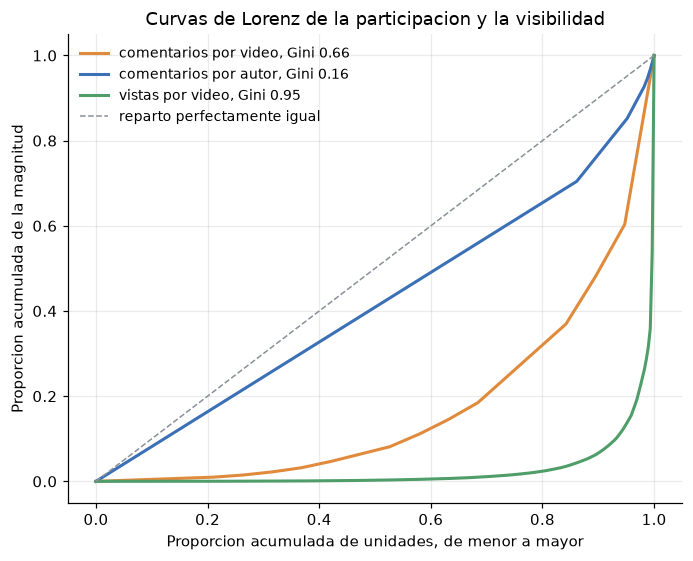

In [27]:
fig, ax = plt.subplots(figsize=(6.4, 5.2))

for serie, etiqueta, color in [
    (comentarios_video_ord, 'comentarios por video', NARANJA),
    (comentarios_autor_ord, 'comentarios por autor', AZUL),
    (videos['view_count'], 'vistas por video', VERDE),
]:
    x = np.sort(np.asarray(serie, dtype=float))
    acumulado = np.insert(np.cumsum(x) / x.sum(), 0, 0)
    poblacion = np.linspace(0, 1, len(acumulado))
    ax.plot(poblacion, acumulado, color=color, linewidth=2,
            label=f'{etiqueta}, Gini {gini(x):.2f}')

ax.plot([0, 1], [0, 1], color=GRIS, linestyle='--', linewidth=1, label='reparto perfectamente igual')
ax.set_xlabel('Proporcion acumulada de unidades, de menor a mayor')
ax.set_ylabel('Proporcion acumulada de la magnitud')
ax.set_title('Curvas de Lorenz de la participacion y la visibilidad')
ax.legend(loc='upper left', frameon=False, fontsize=9)
plt.show()

La participacion esta fuertemente concentrada en los tres niveles. Un solo video reune 161 de los
406 comentarios, casi el 40 por ciento del total, y con tres videos ya se supera la mitad. Del lado
de los canales, Quorum concentra 256 comentarios, mas del 60 por ciento, pese a que no es el canal
que mas publica.

La curva de Lorenz muestra que las vistas estan aun mas concentradas que los comentarios, con un
Gini de 0.95 frente a 0.66 para los comentarios por video. Es decir, la visibilidad se reparte de
forma todavia mas desigual que la conversacion.

Del lado de los autores la concentracion es baja, no porque el reparto sea equitativo sino por lo
contrario: casi todos aportan exactamente un comentario, asi que hay poca variacion que concentrar.
Es un piso plano con muy pocos usuarios recurrentes por encima.

### 3.3 Popularidad frente a participacion

In [28]:
comparacion = (
    resumen_videos_comentados[['video_id', 'title', 'channel_name', 'view_count', 'n_comentarios', 'n_autores']]
    .copy()
)

pearson = comparacion['view_count'].corr(comparacion['n_comentarios'])
spearman = comparacion['view_count'].corr(comparacion['n_comentarios'], method='spearman')
pearson_log = np.log10(comparacion['view_count']).corr(np.log10(comparacion['n_comentarios']))

print(f'Pearson entre vistas y comentarios: {pearson:.2f}')
print(f'Spearman entre vistas y comentarios: {spearman:.2f}')
print(f'Pearson sobre logaritmos: {pearson_log:.2f}')
print()

comparacion['comentarios_por_mil_vistas'] = comparacion['n_comentarios'] / comparacion['view_count'] * 1000
print('Videos ordenados por comentarios cada mil vistas:')
print(comparacion.sort_values('comentarios_por_mil_vistas', ascending=False)
      [['channel_name', 'title', 'view_count', 'n_comentarios', 'comentarios_por_mil_vistas']]
      .round(2).to_string(index=False, max_colwidth=42))

Pearson entre vistas y comentarios: 0.07
Spearman entre vistas y comentarios: 0.81
Pearson sobre logaritmos: 0.72

Videos ordenados por comentarios cada mil vistas:
                         channel_name                                      title  view_count  n_comentarios  comentarios_por_mil_vistas
                               Quorum Edén por Salud: empleo inclusivo para p...          52              1                       19.23
                               Quorum            Internet: escoger el menos malo         717             12                       16.74
                               Quorum    Caminar en una ciudad hecha para carros         422              6                       14.22
                               Quorum                  Qué rico come tu diputado       11775            161                       13.67
                               Quorum             Arroz con pollo a la MONOPOLIO        1954             16                        8.19
Gobierno de la Repú

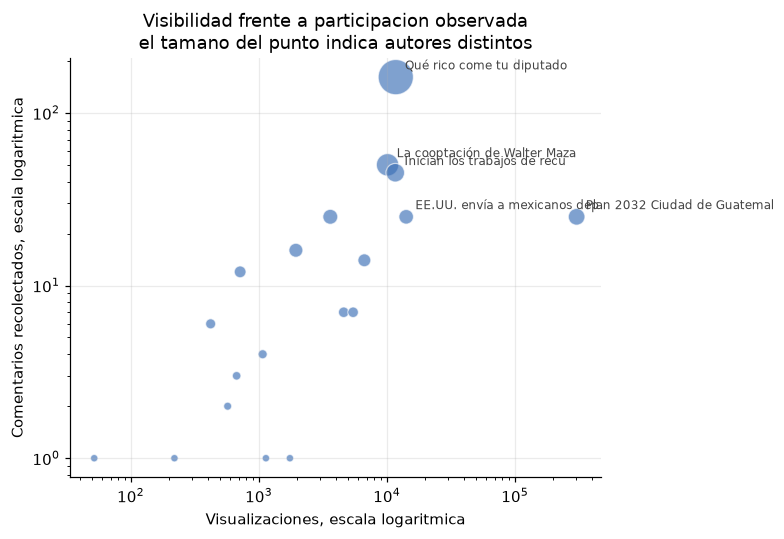

In [29]:
fig, ax = plt.subplots(figsize=(7.2, 5))

ax.scatter(comparacion['view_count'], comparacion['n_comentarios'],
           s=comparacion['n_autores'] * 4 + 20, color=AZUL, alpha=0.65, edgecolor='white', linewidth=0.8)

destacados = comparacion.nlargest(3, 'n_comentarios').index.union(comparacion.nlargest(2, 'view_count').index)
for i in destacados:
    fila = comparacion.loc[i]
    ax.annotate(fila['title'][:28], (fila['view_count'], fila['n_comentarios']),
                textcoords='offset points', xytext=(6, 5), fontsize=8, color='#444')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Visualizaciones, escala logaritmica')
ax.set_ylabel('Comentarios recolectados, escala logaritmica')
ax.set_title('Visibilidad frente a participacion observada\nel tamano del punto indica autores distintos')
plt.show()

La correlacion de Pearson sobre los valores crudos es de 0.07, practicamente nula, mientras que la
correlacion de rangos de Spearman llega a 0.81. La razon se ve en la grafica: el Plan 2032 de la
Municipalidad tiene 304 mil vistas, veinte veces mas que cualquier otro video comentado, y sin
embargo reune 25 comentarios, una cifra normal en este conjunto. Ese unico punto arrastra por
completo la correlacion lineal. Al comparar ordenes en lugar de magnitudes, o al trabajar en escala
logaritmica, donde Pearson sube a 0.72, si aparece una relacion positiva clara.

La lectura razonable es que mas vistas tienden a venir con mas comentarios, pero no de forma
proporcional. La columna de comentarios cada mil vistas lo deja claro: el video mas visto de la
muestra comentada tiene la tasa mas baja de todas, 0.08 comentarios por cada mil vistas, mientras
que varios videos pequenos de Quorum superan los 13.

Las dos limitaciones de esta comparacion son importantes. Primero, view_count es un conteo
acumulado desde la publicacion del video, mientras que los comentarios aqui no son todos los del
video sino solo los recolectados, de modo que estamos comparando un censo con una muestra.
Segundo, solo hay 19 videos con comentarios, una base demasiado pequena para afirmar una relacion
estable.

### 3.4 Visualizaciones

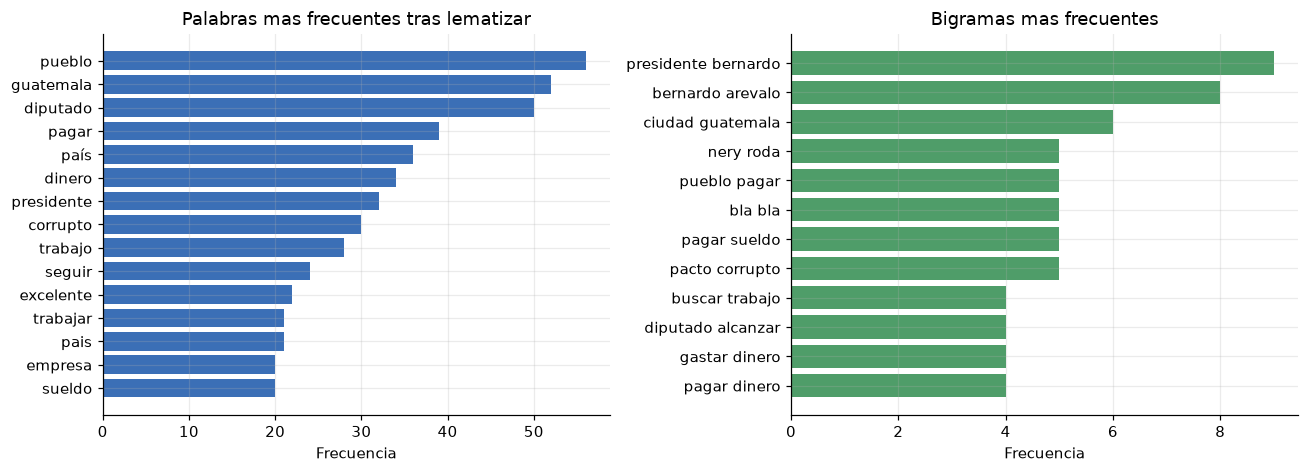

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

palabras_top = frecuencia_palabras.most_common(15)[::-1]
axes[0].barh([p for p, _ in palabras_top], [n for _, n in palabras_top], color=AZUL)
axes[0].set_xlabel('Frecuencia')
axes[0].set_title('Palabras mas frecuentes tras lematizar')

bigramas_top = frecuencia_bigramas.most_common(12)[::-1]
axes[1].barh([' '.join(b) for b, _ in bigramas_top], [n for _, n in bigramas_top], color=VERDE)
axes[1].set_xlabel('Frecuencia')
axes[1].set_title('Bigramas mas frecuentes')

plt.show()

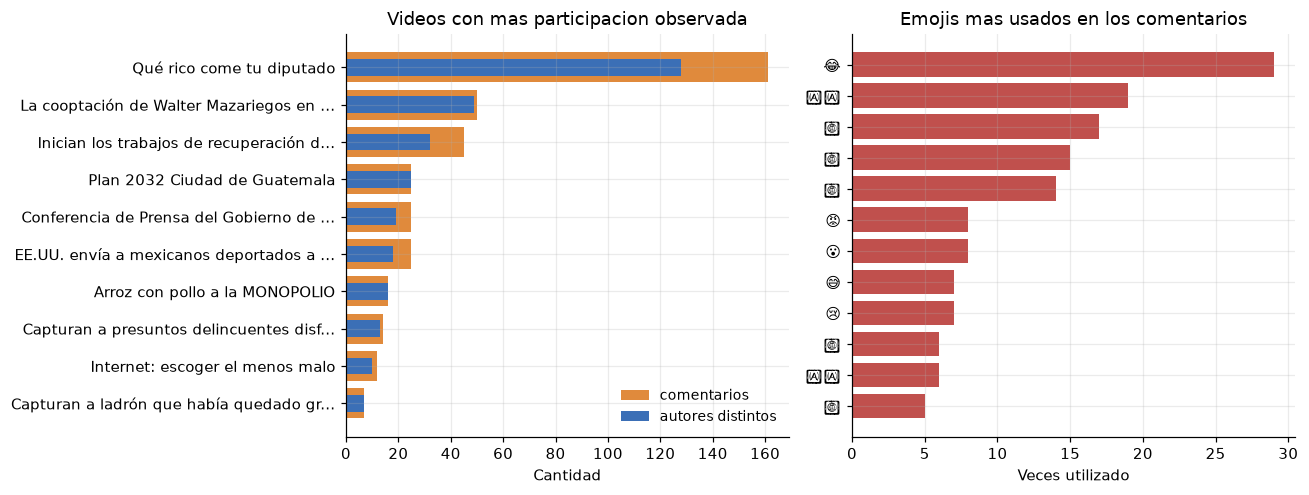

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

top_videos = resumen_videos_comentados.head(10)[::-1]
etiquetas = [f'{t[:38]}...' if len(t) > 38 else t for t in top_videos['title']]
axes[0].barh(etiquetas, top_videos['n_comentarios'], color=NARANJA, label='comentarios')
axes[0].barh(etiquetas, top_videos['n_autores'], color=AZUL, height=0.45, label='autores distintos')
axes[0].set_xlabel('Cantidad')
axes[0].set_title('Videos con mas participacion observada')
axes[0].legend(frameon=False, fontsize=9)

emojis_top = frecuencia_emojis.most_common(12)[::-1]
axes[1].barh([e for e, _ in emojis_top], [n for _, n in emojis_top], color=ROJO)
axes[1].set_xlabel('Veces utilizado')
axes[1].set_title('Emojis mas usados en los comentarios')

plt.show()

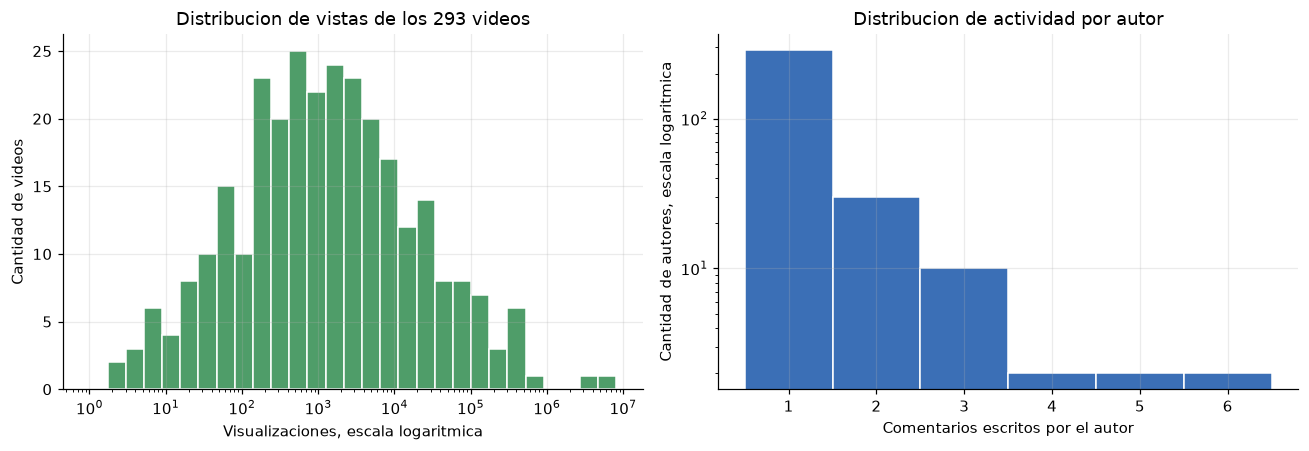

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].hist(videos['view_count'], bins=np.logspace(0, np.log10(videos['view_count'].max()), 30),
             color=VERDE, edgecolor='white')
axes[0].set_xscale('log')
axes[0].set_xlabel('Visualizaciones, escala logaritmica')
axes[0].set_ylabel('Cantidad de videos')
axes[0].set_title('Distribucion de vistas de los 293 videos')

conteo_autor = comments.groupby('author_channel_id').size()
axes[1].hist(conteo_autor, bins=np.arange(0.5, conteo_autor.max() + 1.5), color=AZUL, edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_xlabel('Comentarios escritos por el autor')
axes[1].set_ylabel('Cantidad de autores, escala logaritmica')
axes[1].set_title('Distribucion de actividad por autor')

plt.show()

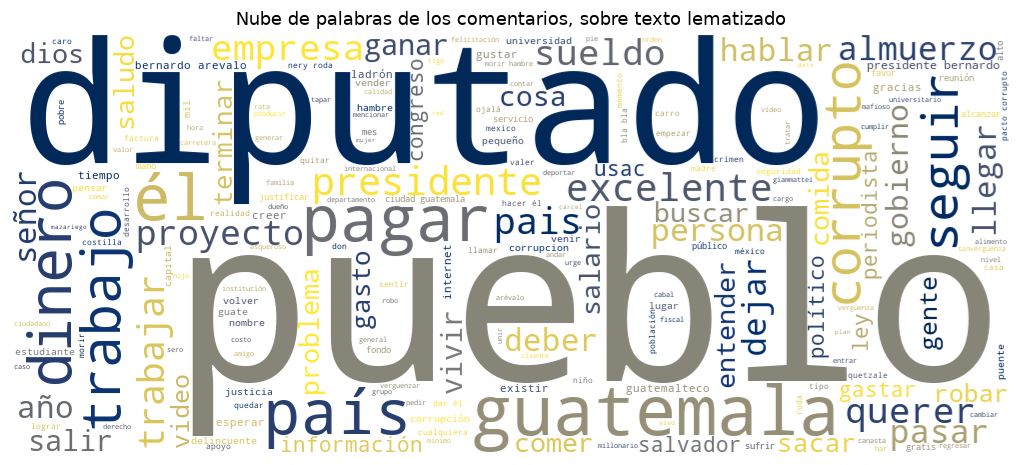

In [33]:
texto_para_nube = ' '.join(comments['texto_limpio'])

nube = WordCloud(width=1000, height=420, background_color='white',
                 colormap='cividis', random_state=SEMILLA).generate(texto_para_nube)

fig, ax = plt.subplots(figsize=(10, 4.3))
ax.imshow(nube, interpolation='bilinear')
ax.axis('off')
ax.grid(False)
ax.set_title('Nube de palabras de los comentarios, sobre texto lematizado')
plt.show()

Las graficas de barras son el analisis principal porque permiten comparar magnitudes exactas. La
nube de palabras va como complemento visual: transmite el tono general de la conversacion pero no
deja leer cuanto mas frecuente es una palabra que otra.

Las dos distribuciones del ultimo panel resumen la forma del conjunto. Las vistas se reparten en
varios ordenes de magnitud y por eso siempre las graficamos en escala logaritmica. La actividad por
autor cae de golpe: la enorme mayoria escribio un solo comentario y el maximo son seis.

La grafica de videos superpone comentarios y autores distintos. Las dos barras casi coinciden en
todos los videos, lo que confirma que la participacion viene de muchas personas que intervienen una
vez y no de unas pocas que comentan repetidamente.

### 3.5 Preguntas obligatorias

In [34]:
comentarios_por_canal = (
    comments.groupby('channel_id').size().rename('n_comentarios').reset_index()
    .merge(comments[['channel_id', 'channel_name']].drop_duplicates(), on='channel_id')
    .merge(videos.groupby('channel_id').size().rename('n_videos').reset_index(), on='channel_id')
    .sort_values('n_comentarios', ascending=False)
)
comentarios_por_canal['pct_comentarios'] = (
    comentarios_por_canal['n_comentarios'] / len(comments) * 100).round(1)

print('Participacion por canal:')
print(comentarios_por_canal[['channel_name', 'n_videos', 'n_comentarios', 'pct_comentarios']]
      .to_string(index=False))
print()

videos_por_autor = comments.groupby('author_channel_id')['video_id'].nunique()
puentes = videos_por_autor[videos_por_autor > 1].sort_values(ascending=False)
print(f'Autores que comentaron en mas de un video: {len(puentes)} de {len(videos_por_autor)}')
detalle_puentes = (
    comments[comments['author_channel_id'].isin(puentes.index)]
    .groupby(['author_channel_id', 'author_name'])
    .agg(videos=('video_id', 'nunique'), comentarios=('comment_id', 'size'),
         canales=('channel_name', 'nunique'))
    .sort_values(['videos', 'comentarios'], ascending=False)
)
print(detalle_puentes.to_string())

Participacion por canal:
                         channel_name  n_videos  n_comentarios  pct_comentarios
                               Quorum        18            256             63.1
Gobierno de la República de Guatemala        32             70             17.2
                   Noticias Telemundo         2             25              6.2
           Municipalidad de Guatemala        27             25              6.2
                                Noti7         3             14              3.4
                   PrensaLibreOficial        17              7              1.7
                       TN23 Guatemala         7              7              1.7
        Noticiero Guatevisión 13 Hrs.         2              2              0.5

Autores que comentaron en mas de un video: 9 de 332
                                               videos  comentarios  canales
author_channel_id        author_name                                       
UCvcu1kR8xMYy_I1Ty-2mV2Q @hashojea7348            

#### Que videos y canales concentran la mayor participacion observada

Un solo video de Quorum, Que rico come tu diputado, reune 161 de los 406 comentarios. A nivel de
canal, Quorum concentra 256 comentarios con 18 videos, mas del 60 por ciento del total, mientras
que el canal del Gobierno de la Republica de Guatemala publico 32 videos y recibio 70 comentarios.
Publicar mas no equivale a generar mas conversacion.

#### Existen audiencias compartidas entre videos, canales o temas

Existen, pero son minimas. Solo 9 de los 332 autores comentaron en mas de un video y ninguno
supera tres videos. La mayoria de esos solapamientos ocurre entre videos de tema politico del mismo
canal, lo que sugiere audiencias tematicas mas que audiencias que circulen entre canales. La
seccion 5 cuantifica esto con la proyeccion video-video.

#### Que autores funcionan como puentes entre contenidos que de otra forma permanecerian separados

Son esos mismos 9 autores, y dentro de ellos destacan dos que comentaron en tres videos distintos.
En la seccion 8 los identificamos formalmente por intermediacion y confirmamos que al quitarlos la
red se parte en mas componentes.

#### Que temas y sentimientos caracterizan a las principales comunidades de participacion

El vocabulario dominante es politico y critico, con pueblo, dinero, diputado, corrupto y presidente
a la cabeza. El analisis formal de sentimiento esta en la seccion 9 y la caracterizacion por
comunidad en el punto 9.2, donde se confirma un tono mayoritariamente negativo con una excepcion
clara en el video de planificacion urbana de la Municipalidad.

#### La visibilidad medida mediante visualizaciones coincide con la participacion observada

Coincide en orden pero no en magnitud. La correlacion de rangos llega a 0.81 mientras que la lineal
se queda en 0.07, arrastrada por un video con 304 mil vistas y solo 25 comentarios. Ademas la
comparacion es asimetrica, porque las vistas son un censo acumulado desde la publicacion y los
comentarios son una muestra recolectada en un instante.

#### Que conclusiones estan limitadas por el procedimiento de recoleccion y la cobertura de los datos

La limitacion principal es que solo 19 de los 293 videos tienen comentarios, de modo que todo lo
que decimos sobre autores y conversacion vale para esos 19 videos y no para el conjunto. Ademas los
videos entraron por consultas de busqueda con sesgo tematico hacia noticias y gobierno de
Guatemala, las fechas de los comentarios son relativas y no permiten ordenar eventos, y los conteos
de vistas y me gusta corresponden al instante de la recoleccion.

### 3.6 Preguntas adicionales

#### El canal que mas videos publico es tambien el que recibe mas comentarios

In [35]:
canal_mas_videos = videos_por_canal.idxmax()
canal_mas_comentarios = comentarios_por_canal.iloc[0]

nombre_mas_videos = videos.loc[videos['channel_id'] == canal_mas_videos, 'channel_name'].iloc[0]
print(f'Canal con mas videos publicados: {nombre_mas_videos}, {videos_por_canal.max()} videos.')
print(f'Canal con mas comentarios recibidos: {canal_mas_comentarios["channel_name"]}, '
      f'{canal_mas_comentarios["n_comentarios"]} comentarios con {canal_mas_comentarios["n_videos"]} videos.')
print()
print('Comentarios por video publicado, entre los canales con comentarios:')
tasa = comentarios_por_canal.assign(
    comentarios_por_video=lambda d: (d['n_comentarios'] / d['n_videos']).round(1)
).sort_values('comentarios_por_video', ascending=False)
print(tasa[['channel_name', 'n_videos', 'n_comentarios', 'comentarios_por_video']].to_string(index=False))

Canal con mas videos publicados: Gobierno de la República de Guatemala, 32 videos.
Canal con mas comentarios recibidos: Quorum, 256 comentarios con 18 videos.

Comentarios por video publicado, entre los canales con comentarios:
                         channel_name  n_videos  n_comentarios  comentarios_por_video
                               Quorum        18            256                   14.2
                   Noticias Telemundo         2             25                   12.5
                                Noti7         3             14                    4.7
Gobierno de la República de Guatemala        32             70                    2.2
        Noticiero Guatevisión 13 Hrs.         2              2                    1.0
                       TN23 Guatemala         7              7                    1.0
           Municipalidad de Guatemala        27             25                    0.9
                   PrensaLibreOficial        17              7                    0.

No coinciden. El canal del Gobierno publico 32 videos y el que mas conversacion genera es Quorum
con 18. La diferencia se agranda al mirar comentarios por video publicado. Lo que predice la
participacion en estos datos es el tipo de contenido, no el volumen de publicacion, aunque hay que
recordar que la recoleccion de comentarios no cubrio todos los videos de cada canal.

#### Los comentarios con mas me gusta son mas largos o mas emotivos

In [36]:
comments['largo_caracteres'] = comments['texto_original'].str.len()
comments['n_emojis'] = comments['emojis'].apply(len)

print('Correlacion de me gusta con otras variables del comentario:')
for columna, etiqueta in [('largo_caracteres', 'largo en caracteres'),
                          ('n_emojis', 'cantidad de emojis'),
                          ('reply_count', 'respuestas recibidas')]:
    pearson_c = comments['like_count'].corr(comments[columna])
    spearman_c = comments['like_count'].corr(comments[columna], method='spearman')
    print(f'  {etiqueta}: Pearson {pearson_c:.2f}, Spearman {spearman_c:.2f}')

print()
cuartiles = pd.qcut(comments['largo_caracteres'], 4, labels=['mas cortos', 'cortos', 'largos', 'mas largos'])
print('Me gusta segun cuartil de longitud del comentario:')
print(comments.groupby(cuartiles, observed=True)['like_count'].agg(['count', 'mean', 'median']).round(2).to_string())

Correlacion de me gusta con otras variables del comentario:
  largo en caracteres: Pearson -0.03, Spearman -0.00
  cantidad de emojis: Pearson -0.03, Spearman -0.04
  respuestas recibidas: Pearson 0.54, Spearman 0.25

Me gusta segun cuartil de longitud del comentario:
                  count  mean  median
largo_caracteres                     
mas cortos          103  7.34     1.0
cortos              100  8.15     1.0
largos              101  2.33     1.0
mas largos          102  5.09     1.0


No existe tal relacion. Tanto la correlacion de Pearson como la de rangos entre longitud y me gusta
son practicamente cero, y la tabla por cuartiles no muestra ninguna tendencia: la mediana es de un
me gusta en los cuatro cuartiles y el promedio mas alto corresponde a comentarios cortos, no a los
largos. La cantidad de emojis tampoco aporta nada. Un comentario breve puede recibir tantos me
gusta como uno extenso.

La unica relacion apreciable es entre me gusta y respuestas recibidas, con Pearson de 0.54 y
Spearman de 0.25. Es esperable, porque las dos variables miden atencion sobre el mismo comentario y
no una propiedad de su redaccion. Lo que si predice los me gusta, como veremos en la seccion 9, es
el tono del comentario.

#### La estrategia de recoleccion cambia lo que observamos

In [37]:
print('Comentarios y participacion segun la estrategia con la que se encontro el video:')
por_origen = comments.groupby('source_group').agg(
    comentarios=('comment_id', 'size'),
    videos=('video_id', 'nunique'),
    autores=('author_channel_id', 'nunique'),
    likes_promedio=('like_count', 'mean'),
).round(2)
por_origen['comentarios_por_video'] = (por_origen['comentarios'] / por_origen['videos']).round(1)
print(por_origen.to_string())
print()
print('Videos disponibles por estrategia frente a videos con comentarios:')
comparativa_origen = pd.DataFrame({
    'videos_en_el_conjunto': videos['source_group'].value_counts(),
    'videos_con_comentarios': videos[videos['video_id'].isin(comments['video_id'])]['source_group'].value_counts(),
}).fillna(0).astype(int)
comparativa_origen['cobertura'] = (
    comparativa_origen['videos_con_comentarios'] / comparativa_origen['videos_en_el_conjunto'] * 100).round(1)
print(comparativa_origen.to_string())

Comentarios y participacion segun la estrategia con la que se encontro el video:
              comentarios  videos  autores  likes_promedio  comentarios_por_video
source_group                                                                     
channel               231      11      192            1.72                   21.0
topic                 175       9      144           11.01                   19.4

Videos disponibles por estrategia frente a videos con comentarios:
              videos_en_el_conjunto  videos_con_comentarios  cobertura
source_group                                                          
channel                          11                       7       63.6
official_gov                    105                       0        0.0
topic                           177                      12        6.8


Si cambia, y es una advertencia metodologica importante. Los videos recolectados por consulta
tematica y los recolectados por canal producen volumenes de conversacion muy distintos, y la
cobertura de comentarios tampoco es pareja entre estrategias. La categoria official_gov aporta 105
videos al conjunto pero muy pocos con comentarios recolectados. Cualquier comparacion entre grupos
de origen mide, en parte, como se hizo la recoleccion y no solo como se comporta la audiencia.

## 4. Construccion de la red bipartita autor-video

### 4.1 y 4.2 Definicion y construccion

Construimos una red bipartita no dirigida con dos conjuntos disjuntos de nodos. El primero son los
autores, identificados por author_channel_id. El segundo son los videos, identificados por
video_id. Nunca hay una arista entre dos autores ni entre dos videos.

Existe una arista entre un autor y un video cuando ese autor publico al menos un comentario en ese
video, y el peso de la arista es la cantidad de comentarios que ese autor publico ahi. La red es no
dirigida porque el dato solo registra el hecho de comentar, sin ninguna direccion interpretable, y
porque los datos no permiten saber quien respondio a quien.

In [38]:
pares_autor_video = (
    comments.groupby(['author_channel_id', 'video_id']).size().reset_index(name='peso')
)

print('Pares autor-video distintos, es decir aristas:', len(pares_autor_video))
print('Suma de pesos, que debe igualar el total de comentarios:', int(pares_autor_video['peso'].sum()))
print()
print('Distribucion de los pesos:')
print(pares_autor_video['peso'].value_counts().sort_index().rename('aristas').to_string())

Pares autor-video distintos, es decir aristas: 343
Suma de pesos, que debe igualar el total de comentarios: 406

Distribucion de los pesos:
peso
1    303
2     28
3      7
4      1
5      2
6      2


In [39]:
G = nx.Graph()

atributos_video = resumen_videos_comentados.set_index('video_id')

for autor, grupo in comments.groupby('author_channel_id'):
    G.add_node(
        autor,
        tipo='autor',
        bipartite=0,
        nombre=grupo['author_name'].iloc[0],
        handle=grupo['author_handle'].iloc[0],
        n_comentarios=len(grupo),
        likes_recibidos=int(grupo['like_count'].sum()),
    )

for video_id, fila in atributos_video.iterrows():
    G.add_node(
        video_id,
        tipo='video',
        bipartite=1,
        titulo=fila['title'],
        canal=fila['channel_name'],
        categoria=fila['category'],
        vistas=int(fila['view_count']),
        n_comentarios=int(fila['n_comentarios']),
    )

for fila in pares_autor_video.itertuples(index=False):
    G.add_edge(fila.author_channel_id, fila.video_id, peso=int(fila.peso))

nodos_autor = [n for n, d in G.nodes(data=True) if d['tipo'] == 'autor']
nodos_video = [n for n, d in G.nodes(data=True) if d['tipo'] == 'video']

print('Es bipartita:', nx.is_bipartite(G))
print('Nodos totales:', G.number_of_nodes(), 'de los cuales', len(nodos_autor), 'autores y',
      len(nodos_video), 'videos')
print('Aristas:', G.number_of_edges())

Es bipartita: True
Nodos totales: 351 de los cuales 332 autores y 19 videos
Aristas: 343


Los 332 autores del conjunto aparecen como nodo porque por definicion cada uno escribio al menos un
comentario. Del lado de los videos entran solo los 19 que recibieron comentarios recolectados. Los
otros 274 videos no pueden tener ninguna arista en esta red, y esa ausencia es un limite del dato y
no una propiedad de los videos.

La suma de los pesos coincide exactamente con los 406 comentarios, lo que confirma que la
construccion no pierde ni duplica informacion.

### 4.3 Tabla de nodos y tabla de aristas

In [40]:
tabla_nodos = pd.DataFrame([
    {
        'id': nodo,
        'tipo': datos['tipo'],
        'etiqueta': datos.get('nombre') if datos['tipo'] == 'autor' else datos.get('titulo'),
        'canal': datos.get('canal', ''),
        'categoria': datos.get('categoria', ''),
        'vistas': datos.get('vistas', np.nan),
        'n_comentarios': datos.get('n_comentarios', np.nan),
        'likes_recibidos': datos.get('likes_recibidos', np.nan),
        'grado': G.degree(nodo),
        'grado_ponderado': G.degree(nodo, weight='peso'),
    }
    for nodo, datos in G.nodes(data=True)
])

print('Tabla de nodos:', tabla_nodos.shape)
print(tabla_nodos['tipo'].value_counts().to_string())
tabla_nodos.sort_values(['tipo', 'grado'], ascending=[True, False]).head(12)

Tabla de nodos: (351, 10)
tipo
autor    332
video     19


,id,tipo,etiqueta,canal,categoria,vistas,n_comentarios,likes_recibidos,grado,grado_ponderado
276,UCpsKOkt5iWTbenzeuq7dsmQ,autor,@inge_vergueta,,,NaN,3,4.0,3,3
307,UCvcu1kR8xMYy_I1Ty-2mV2Q,autor,@hashojea7348,,,NaN,4,0.0,3,4
98,UCHTGCgY2l-DQJIvlA_cpa_Q,autor,@virgiliogarcia3039,,,NaN,3,14.0,2,3
207,UCbrtvygfRT6QXqWDNrOf-cA,autor,@Alejandro00710,,,NaN,2,0.0,2,2
211,UCdFlugHJJa4l3YqWuNRmvXw,autor,@MarcosCarillo-b1r,,,NaN,2,0.0,2,2
250,UCjZgFEowMBrsjodqfovzdKw,autor,@franciscoflores3120,,,NaN,2,0.0,2,2
287,UCsUCN0Yq_UyTvKjOJLmNrnQ,autor,@moisesvaldez4043,,,NaN,2,0.0,2,2
325,UCylqlpsh8ENNM1LqgQ1KbxA,autor,@Jel.Awesh.M,,,NaN,3,1.0,2,3
330,UCzZ6dDCEsLMXbc5pCFXIprw,autor,@josegil3813,,,NaN,2,0.0,2,2
0,UC-HeUTT6_g-VoiWds2a4H-w,autor,@JorgeMunoz-gd9et,,,NaN,1,0.0,1,1


In [41]:
tabla_aristas = nx.to_pandas_edgelist(G, source='autor', target='video')
tabla_aristas['autor_nombre'] = tabla_aristas['autor'].map(lambda n: G.nodes[n]['nombre'])
tabla_aristas['video_titulo'] = tabla_aristas['video'].map(lambda n: G.nodes[n]['titulo'])
tabla_aristas['canal'] = tabla_aristas['video'].map(lambda n: G.nodes[n]['canal'])
tabla_aristas = tabla_aristas[['autor', 'video', 'peso', 'autor_nombre', 'video_titulo', 'canal']]

print('Tabla de aristas:', tabla_aristas.shape)
tabla_aristas.sort_values('peso', ascending=False).head(10)

Tabla de aristas: (343, 6)


,autor,video,peso,autor_nombre,video_titulo,canal
244,UCi2KiZq63sRq8Mfbcp-MelQ,OkXlHx0hx-8,6,@eugeneramirez4405,EE.UU. envía a mexicanos deportados a Guatemal...,Noticias Telemundo
331,UCyJhqmMbsvjpoarBBStA2kg,6W4u8sGEnGM,6,@Murmullodelbarrio,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala
33,UC5H8ASmMC9WrURmzeB4ySog,n8iP75gIpmw,5,@ManuelEdran,Qué rico come tu diputado,Quorum
165,UCV3fr-YOixFKCZBbJP1-X4w,6W4u8sGEnGM,5,@albertoshernandez5251,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala
57,UC9vMq1YF-e7C-VO0SHkbUTA,n8iP75gIpmw,4,@ErvinLeonardoCarreraLatín,Qué rico come tu diputado,Quorum
25,UC3XTwHxygNCgjndsg-UiCQA,n8iP75gIpmw,3,@marioajset4283,Qué rico come tu diputado,Quorum
46,UC72gBAtyb_VXQlYDcFrh6oQ,n8iP75gIpmw,3,@osmanmorales3012,Qué rico come tu diputado,Quorum
85,UCFjudnPLoaSL1BaRuLahyHg,n8iP75gIpmw,3,@HaroldoCastillo-rh9iw,Qué rico come tu diputado,Quorum
120,UCNIeXbV_mEwpa412h1aqUWw,PjmxCj-a9Hg,3,@juandeleon9060,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala
226,UCg3eIfd7BrsLEqS0BLkftHA,PjmxCj-a9Hg,3,@ErmePérez-q4s,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala


In [42]:
tabla_nodos.to_csv('salidas/tabla_nodos_bipartita.csv', index=False)
tabla_aristas.to_csv('salidas/tabla_aristas_bipartita.csv', index=False)
print('Tablas exportadas a la carpeta salidas.')

Tablas exportadas a la carpeta salidas.


La tabla de nodos incluye el tipo de nodo y los atributos propios de cada tipo. Para los autores
guardamos el nombre visible, cuantos comentarios escribio y cuantos me gusta recibio en total. Para
los videos guardamos el titulo, el canal, la categoria de YouTube, las vistas y los comentarios
recolectados. Ambos tipos llevan grado y grado ponderado.

La tabla de aristas lleva el par de identificadores, el peso y las etiquetas legibles para
inspeccion. Casi todas las aristas tienen peso uno, es decir que la mayoria de autores comento una
sola vez en el video donde aparece. Los pesos mas altos, de cinco y seis comentarios, corresponden
a unos pocos autores muy insistentes en un mismo video.

Ambas tablas quedan exportadas en la carpeta salidas para poder abrirlas en Gephi o revisarlas sin
ejecutar el notebook.

### 4.4 Visualizacion de la red completa

Dibujamos la red completa con sus 351 nodos y 343 aristas, sin filtrar nodos de grado bajo ni
recortar componentes pequenos. El tamano de cada video es proporcional a su cantidad de comentarios
y los autores que comentaron en mas de un video se dibujan resaltados, porque son los que sostienen
la conexion entre grupos.

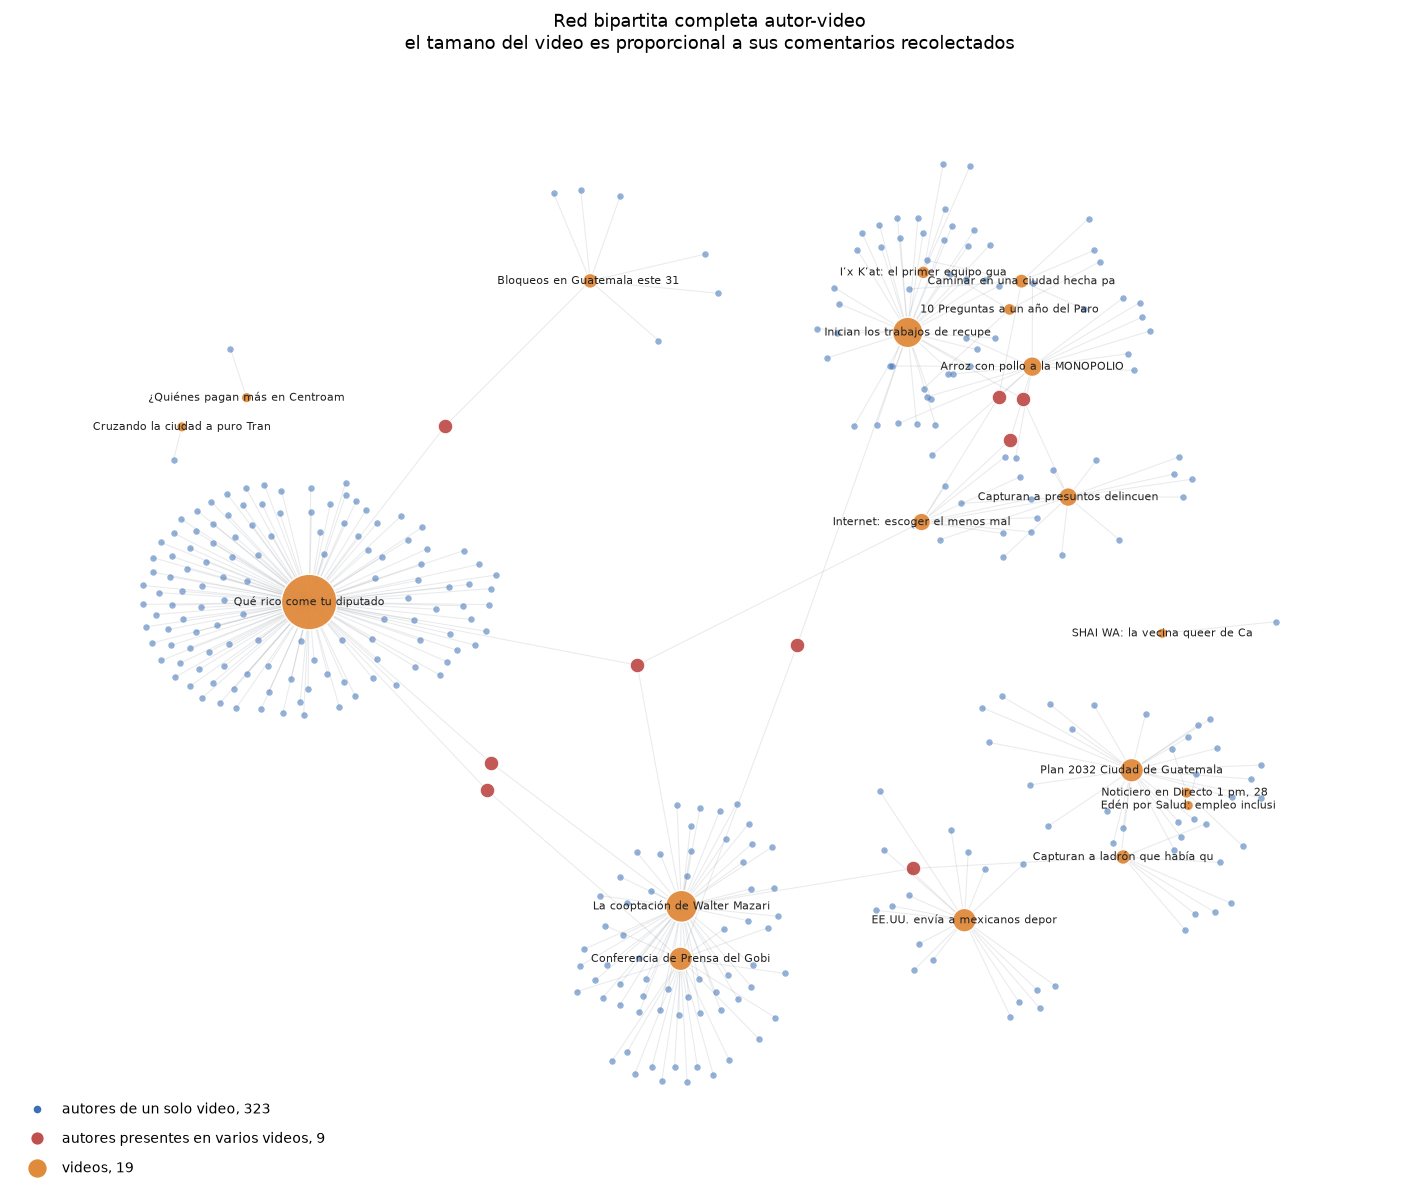

In [43]:
pos = nx.spring_layout(G, k=0.32, iterations=120, seed=SEMILLA, weight=None)

autores_puente = [n for n in nodos_autor if G.degree(n) > 1]
autores_simples = [n for n in nodos_autor if G.degree(n) == 1]
tamano_video = [40 + 8 * G.nodes[n]['n_comentarios'] for n in nodos_video]

fig, ax = plt.subplots(figsize=(13, 11))

nx.draw_networkx_edges(G, pos, alpha=0.18, width=0.7, edge_color=GRIS, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=autores_simples, node_color=AZUL, node_size=18,
                       alpha=0.55, linewidths=0, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=autores_puente, node_color=ROJO, node_size=90,
                       alpha=0.95, edgecolors='white', linewidths=0.6, ax=ax)
nx.draw_networkx_nodes(G, pos, nodelist=nodos_video, node_color=NARANJA, node_size=tamano_video,
                       alpha=0.95, edgecolors='white', linewidths=1.0, ax=ax)

etiquetas_video = {n: G.nodes[n]['titulo'][:30] for n in nodos_video}
nx.draw_networkx_labels(G, pos, labels=etiquetas_video, font_size=7.5, font_color='#222', ax=ax)

leyenda = [
    plt.Line2D([], [], marker='o', linestyle='', color=AZUL, markersize=4,
               label=f'autores de un solo video, {len(autores_simples)}'),
    plt.Line2D([], [], marker='o', linestyle='', color=ROJO, markersize=7,
               label=f'autores presentes en varios videos, {len(autores_puente)}'),
    plt.Line2D([], [], marker='o', linestyle='', color=NARANJA, markersize=11,
               label=f'videos, {len(nodos_video)}'),
]
ax.legend(handles=leyenda, frameon=False, loc='lower left', fontsize=9, labelspacing=1.1)
ax.set_title('Red bipartita completa autor-video\n'
             'el tamano del video es proporcional a sus comentarios recolectados')
ax.margins(0.06)
ax.axis('off')
ax.grid(False)
plt.show()

La estructura se lee de inmediato. Cada video aparece como el centro de una estrella rodeada por
sus propios comentaristas, y la gran mayoria de esos comentaristas cuelga de un unico video. Los
nodos rojos son los pocos autores que comentaron en mas de un video y son los unicos que unen dos
estrellas. Se distinguen tambien varias estrellas completamente separadas del resto, que
corresponden a videos cuyos comentaristas no coinciden con ningun otro video del conjunto.

Esta forma de casi arbol es la razon por la que en la seccion 6 la densidad sale muy baja, la
transitividad de la red bipartita es cero y hay diez componentes conexos.

### 4.5 Que significa una arista y que no significa

Una arista entre un autor y un video significa exactamente una cosa: ese autor publico al menos un
comentario principal en ese video, y el peso indica cuantos. Nada mas.

No significa que el autor apruebe el video ni que este de acuerdo con su contenido. Muchos de los
comentarios de este conjunto son criticas duras al video o a las personas que aparecen en el.

No significa que exista conversacion entre los autores conectados al mismo video. Dos personas
pueden haber comentado con meses de diferencia y no haberse leido nunca. La co-participacion es
coincidencia de espacio, no interaccion.

No significa amistad, afinidad ni pertenencia a una comunidad social. Cuando en la seccion 7
detectamos comunidades, lo que agrupamos son patrones de co-participacion, no vinculos sociales
declarados.

Tampoco podemos construir aristas entre usuarios a partir de reply_count. Esa variable dice cuantas
respuestas recibio un comentario pero no quien las escribio, asi que no identifica ningun par de
autores. La unica relacion que los datos permiten afirmar es que un autor comento en un video, y es
justo eso lo que representa cada arista.

## 5. Proyecciones de la red

Una proyeccion colapsa la red bipartita sobre uno de sus dos conjuntos de nodos. Es la forma
estandar de leer una red de dos modos con herramientas de un modo, y hay que tener presente que
introduce aristas que no existen en el dato original: son inferencias de co-participacion, no
relaciones observadas.

### 5.1 Proyeccion autor-autor

Dos autores quedan conectados si comentaron en el mismo video. El peso de la arista es la cantidad
de videos que ambos comentaron.

In [44]:
P_autores = nx.bipartite.weighted_projected_graph(G, nodos_autor)

for nodo in P_autores.nodes():
    P_autores.nodes[nodo].update(G.nodes[nodo])

print('Proyeccion autor-autor')
print('  nodos:', P_autores.number_of_nodes())
print('  aristas:', P_autores.number_of_edges())
print('  densidad:', round(nx.density(P_autores), 4))
print()
pesos_autor = Counter(nx.get_edge_attributes(P_autores, 'weight').values())
print('Distribucion de pesos, videos compartidos por par de autores:')
for peso in sorted(pesos_autor):
    print(f'  {peso} video(s) en comun: {pesos_autor[peso]} pares')
print()

grados_proyeccion = pd.Series(dict(P_autores.degree())).sort_values(ascending=False)
top_autores_proyeccion = pd.DataFrame({
    'autor': [P_autores.nodes[n]['nombre'] for n in grados_proyeccion.head(10).index],
    'coautores': grados_proyeccion.head(10).values,
    'videos_comentados': [G.degree(n) for n in grados_proyeccion.head(10).index],
    'comentarios': [P_autores.nodes[n]['n_comentarios'] for n in grados_proyeccion.head(10).index],
})
print('Autores con mas co-participantes:')
print(top_autores_proyeccion.to_string(index=False))

Proyeccion autor-autor
  nodos: 332
  aristas: 10732
  densidad: 0.1953

Distribucion de pesos, videos compartidos por par de autores:
  1 video(s) en comun: 10730 pares
  2 video(s) en comun: 2 pares

Autores con mas co-participantes:
               autor  coautores  videos_comentados  comentarios
      @inge_vergueta        183                  3            3
        @Jel.Awesh.M        174                  2            3
 @virgiliogarcia3039        145                  2            3
   @moisesvaldez4043        133                  2            2
     @davidgaher9550        127                  1            1
 @yeniferaguirre4498        127                  1            2
@GilmarMaldonado-q9m        127                  1            1
           @jor77cas        127                  1            1
          @mdelcid01        127                  1            1
 @JosueRamirez-ey3ih        127                  1            1


### 5.2 Proyeccion video-video

Dos videos quedan conectados si comparten al menos un autor. El peso de la arista es la cantidad de
autores que comentaron en ambos.

In [45]:
P_videos = nx.bipartite.weighted_projected_graph(G, nodos_video)

for nodo in P_videos.nodes():
    P_videos.nodes[nodo].update(G.nodes[nodo])

print('Proyeccion video-video')
print('  nodos:', P_videos.number_of_nodes())
print('  aristas:', P_videos.number_of_edges())
print('  densidad:', round(nx.density(P_videos), 4))
print()

aristas_video = pd.DataFrame([
    {
        'canal_a': P_videos.nodes[u]['canal'],
        'video_a': P_videos.nodes[u]['titulo'][:38],
        'canal_b': P_videos.nodes[v]['canal'],
        'video_b': P_videos.nodes[v]['titulo'][:38],
        'autores_compartidos': d['weight'],
    }
    for u, v, d in P_videos.edges(data=True)
]).sort_values('autores_compartidos', ascending=False)

print('Todas las aristas de la proyeccion video-video:')
print(aristas_video.to_string(index=False))
print()
aislados_video = [n for n in P_videos.nodes() if P_videos.degree(n) == 0]
print(f'Videos sin ningun autor en comun con otro video: {len(aislados_video)} de {P_videos.number_of_nodes()}')
for n in aislados_video:
    print(f'  {P_videos.nodes[n]["canal"]}: {P_videos.nodes[n]["titulo"][:55]}')

Proyeccion video-video
  nodos: 19
  aristas: 11
  densidad: 0.0643

Todas las aristas de la proyeccion video-video:
                              canal_a                                video_a                               canal_b                                video_b  autores_compartidos
                               Quorum              Qué rico come tu diputado                                Quorum La cooptación de Walter Mazariegos en                     2
                               Quorum         Arroz con pollo a la MONOPOLIO                                Quorum        Internet: escoger el menos malo                    2
                               Quorum              Qué rico come tu diputado Gobierno de la República de Guatemala Conferencia de Prensa del Gobierno de                     1
                               Quorum              Qué rico come tu diputado                                Quorum        Internet: escoger el menos malo                    1
        

### 5.3 Comparacion entre las dos proyecciones

Las dos proyecciones salen del mismo dato pero describen fenomenos distintos y tienen formas
opuestas.

La proyeccion autor-autor representa audiencias que coincidieron en un mismo espacio. Pasa de 343
aristas bipartitas a mas de diez mil aristas, porque cada video convierte a todos sus comentaristas
en un grupo completamente conectado entre si. El video con 128 comentaristas genera por si solo
mas de ocho mil pares. Esa inflacion es artificial y es la razon por la que su densidad y su
transitividad son enormes: no reflejan sociabilidad sino la aritmetica de la proyeccion. Casi todos
los pares comparten un solo video, y apenas dos pares comparten dos.

La proyeccion video-video representa audiencias compartidas entre contenidos, y es informativa
justamente porque es escasa. Con 19 videos posibles solo aparecen 11 conexiones y nueve videos
quedan completamente aislados. Cada arista aqui si dice algo sustantivo: hubo personas concretas
que comentaron en ambos videos.

En resumen, la proyeccion autor-autor responde a la pregunta de con quien coincidio cada persona, y
tiende a exagerar. La proyeccion video-video responde a que contenidos comparten publico, y en
estos datos es la mas util porque es directamente interpretable y esta ligada a un numero pequeno
de personas identificables.

### 5.4 Visualizacion de las proyecciones

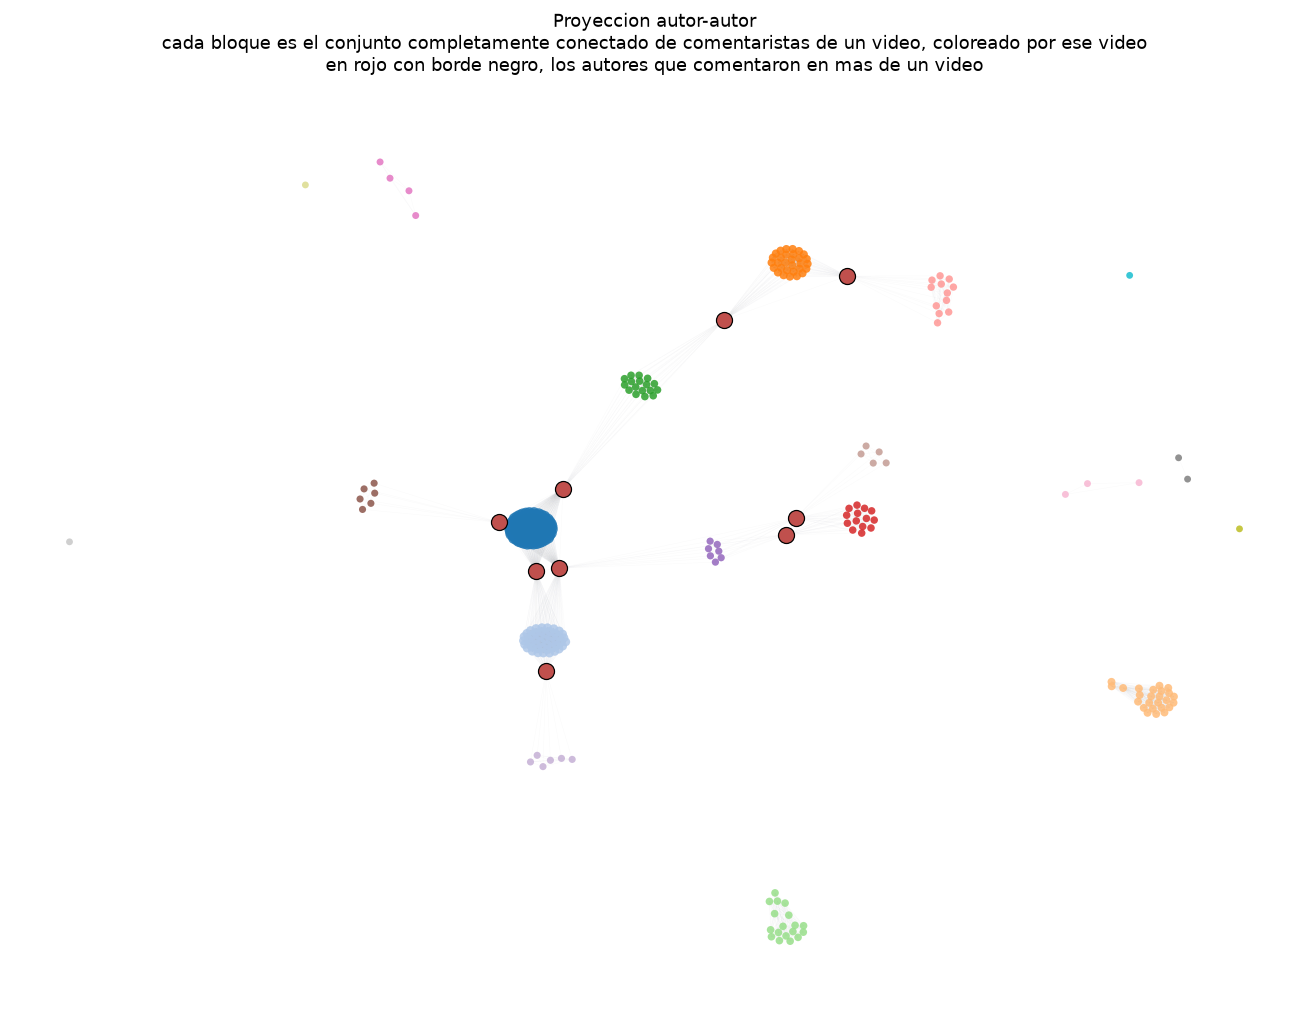

In [46]:
# Coloreamos cada autor segun el video en el que aparece, para que se distingan los bloques.
# Los autores de mas de un video se dibujan aparte, asi que basta con tomar el primero.
video_principal = comments.groupby('author_channel_id')['video_id'].first()
orden_videos = resumen_videos_comentados['video_id'].tolist()
paleta_videos = {v: plt.cm.tab20(i / 19) for i, v in enumerate(orden_videos)}

fig, ax = plt.subplots(figsize=(12, 9.5))

pos_autores = nx.spring_layout(P_autores, k=0.45, iterations=200, seed=SEMILLA)
grados_pa = dict(P_autores.degree())
puentes_pa = [n for n in P_autores.nodes() if G.degree(n) > 1]
simples_pa = [n for n in P_autores.nodes() if G.degree(n) == 1]

nx.draw_networkx_edges(P_autores, pos_autores, alpha=0.035, width=0.35, edge_color=GRIS, ax=ax)
nx.draw_networkx_nodes(P_autores, pos_autores, nodelist=simples_pa,
                       node_color=[paleta_videos[video_principal[n]] for n in simples_pa],
                       node_size=[20 + grados_pa[n] * 0.28 for n in simples_pa],
                       alpha=0.85, linewidths=0, ax=ax)
nx.draw_networkx_nodes(P_autores, pos_autores, nodelist=puentes_pa, node_color=ROJO,
                       node_size=110, alpha=1.0, edgecolors='black', linewidths=0.8, ax=ax)

ax.set_title('Proyeccion autor-autor\n'
             'cada bloque es el conjunto completamente conectado de comentaristas de un video, '
             'coloreado por ese video\n'
             'en rojo con borde negro, los autores que comentaron en mas de un video')
ax.margins(0.05)
ax.axis('off')
ax.grid(False)
plt.show()

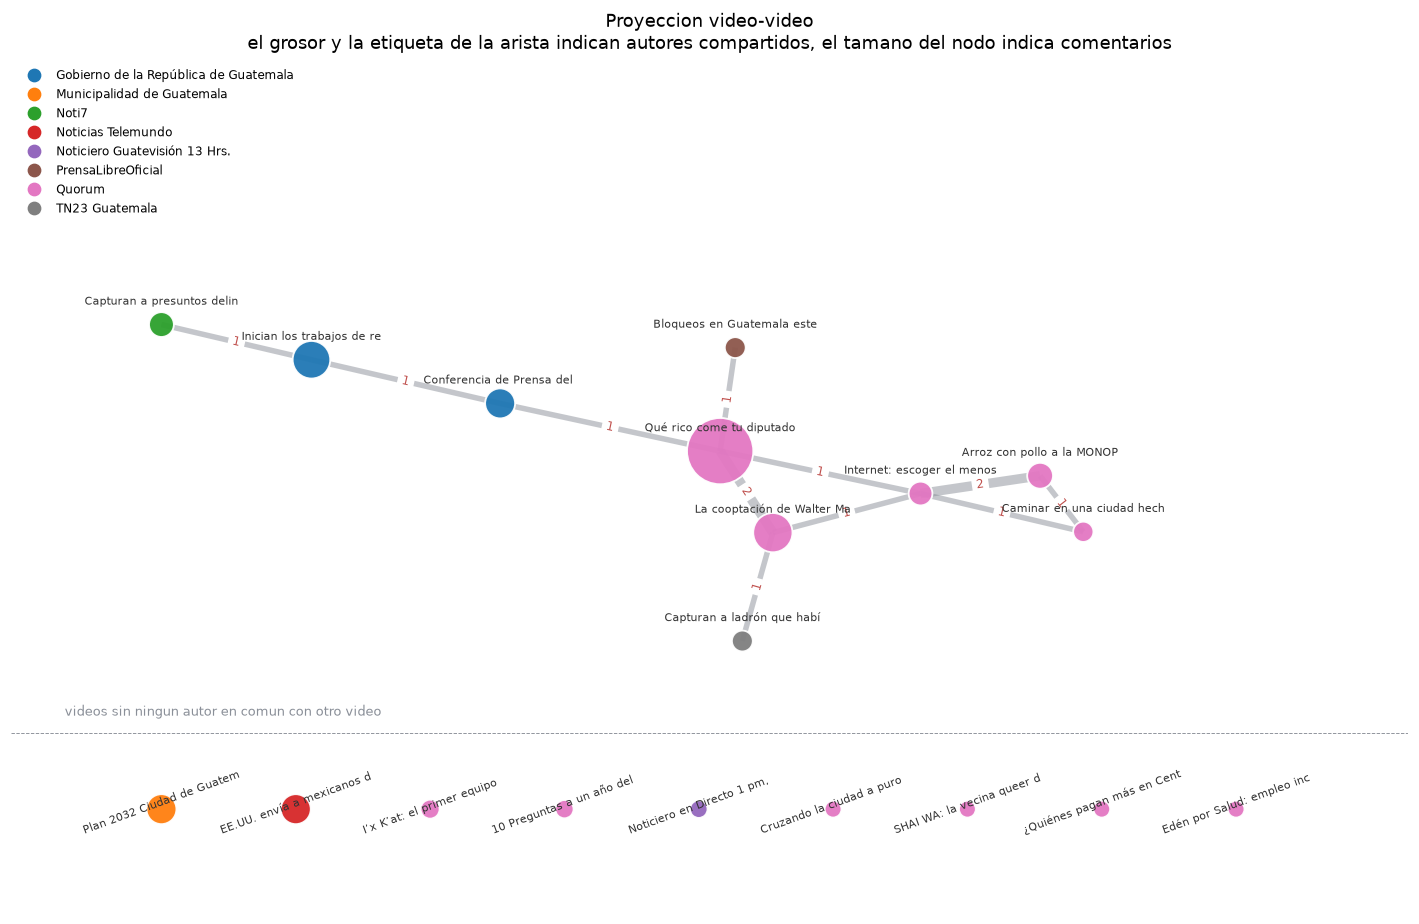

In [47]:
canales_unicos = sorted({P_videos.nodes[n]['canal'] for n in P_videos.nodes()})
paleta_canal = dict(zip(canales_unicos, plt.cm.tab10.colors))

# Colocamos la componente conectada arriba y los videos sin audiencia compartida en una fila abajo,
# para que ninguno quede fuera de la figura y la comparacion sea legible.
conectados = [n for n in P_videos.nodes() if P_videos.degree(n) > 0]
sueltos = [n for n in P_videos.nodes() if P_videos.degree(n) == 0]

pos_videos = nx.spring_layout(P_videos.subgraph(conectados), k=1.1, iterations=300, seed=SEMILLA)
for x, nodo in zip(np.linspace(-1.0, 1.0, len(sueltos)), sueltos):
    pos_videos[nodo] = np.array([x, -1.02])

fig, ax = plt.subplots(figsize=(13, 8.5))

anchos = [1.0 + 2.6 * d['weight'] for _, _, d in P_videos.edges(data=True)]
nx.draw_networkx_edges(P_videos, pos_videos, width=anchos, alpha=0.5, edge_color=GRIS, ax=ax)
nx.draw_networkx_nodes(
    P_videos, pos_videos,
    node_color=[paleta_canal[P_videos.nodes[n]['canal']] for n in P_videos.nodes()],
    node_size=[110 + 11 * P_videos.nodes[n]['n_comentarios'] for n in P_videos.nodes()],
    alpha=0.95, edgecolors='white', linewidths=1.2, ax=ax,
)
nx.draw_networkx_edge_labels(P_videos, pos_videos,
                             edge_labels=nx.get_edge_attributes(P_videos, 'weight'),
                             font_size=8, font_color=ROJO, ax=ax)

for nodo, (x, y) in pos_videos.items():
    suelto = nodo in sueltos
    ax.annotate(P_videos.nodes[nodo]['titulo'][:26],
                (x, y), textcoords='offset points', xytext=(0, -16 if suelto else 13),
                ha='center', fontsize=7.5, rotation=20 if suelto else 0, color='#333')

ax.axhline(-0.8, color=GRIS, linewidth=0.6, linestyle='--')
ax.text(-1.18, -0.75, 'videos sin ningun autor en comun con otro video', fontsize=8.5, color=GRIS)

manijas = [plt.Line2D([], [], marker='o', linestyle='', color=color, label=canal, markersize=8)
           for canal, color in paleta_canal.items()]
ax.legend(handles=manijas, frameon=False, fontsize=8, loc='upper left')
ax.set_title('Proyeccion video-video\n'
             'el grosor y la etiqueta de la arista indican autores compartidos, '
             'el tamano del nodo indica comentarios')
ax.set_xlim(-1.28, 1.32)
ax.set_ylim(-1.32, 1.15)
ax.axis('off')
ax.grid(False)
plt.show()

La primera figura muestra por que la proyeccion autor-autor infla la estructura: se ven bloques
densos, uno por video, en los que todos los puntos estan conectados con todos. Los nodos rojos son
los unicos que aparecen entre dos bloques.

La segunda figura es la mas informativa del conjunto. Solo diez de los diecinueve videos forman un
componente conectado y el resto queda suelto. El nucleo de esa componente son videos de Quorum de
tema politico y urbano, unidos por uno o dos autores cada vez, y a el se enganchan videos de otros
canales como el Gobierno, Noti7, TN23 y Prensa Libre. Las dos aristas de peso dos son las unicas
con mas de una persona en comun.

## 6. Topologia y fragmentacion

### 6.1 Metricas estructurales de las tres redes

Calculamos las mismas metricas para la red bipartita y para las dos proyecciones. Una advertencia
sobre la densidad: en una red bipartita el maximo de aristas posibles no es el de una red completa
sino el producto de los tamanos de los dos conjuntos, asi que reportamos la densidad bipartita
correcta y no la formula general.

In [48]:
def metricas(red, nombre, bipartita=False, conjunto=None):
    componentes = list(nx.connected_components(red))
    mayor = max(componentes, key=len)
    grados = np.array([d for _, d in red.degree()])
    if bipartita:
        densidad = nx.bipartite.density(red, conjunto)
    else:
        densidad = nx.density(red)
    return {
        'red': nombre,
        'nodos': red.number_of_nodes(),
        'aristas': red.number_of_edges(),
        'densidad': round(densidad, 4),
        'grado_medio': round(grados.mean(), 2),
        'grado_mediano': float(np.median(grados)),
        'grado_maximo': int(grados.max()),
        'componentes': len(componentes),
        'mayor_componente': len(mayor),
        'pct_en_mayor': round(100 * len(mayor) / red.number_of_nodes(), 1),
        'aislados': int(sum(1 for _, d in red.degree() if d == 0)),
        'transitividad': round(nx.transitivity(red), 3),
        'clustering_medio': round(nx.average_clustering(red), 3),
    }


tabla_topologia = pd.DataFrame([
    metricas(G, 'bipartita autor-video', bipartita=True, conjunto=nodos_autor),
    metricas(P_autores, 'proyeccion autor-autor'),
    metricas(P_videos, 'proyeccion video-video'),
]).set_index('red').T

print(tabla_topologia.to_string())

red               bipartita autor-video  proyeccion autor-autor  proyeccion video-video
nodos                          351.0000                332.0000                 19.0000
aristas                        343.0000              10732.0000                 11.0000
densidad                         0.0544                  0.1953                  0.0643
grado_medio                      1.9500                 64.6500                  1.1600
grado_mediano                    1.0000                 48.0000                  1.0000
grado_maximo                   128.0000                183.0000                  4.0000
componentes                     10.0000                 10.0000                 10.0000
mayor_componente               286.0000                276.0000                 10.0000
pct_en_mayor                    81.5000                 83.1000                 52.6000
aislados                         0.0000                  4.0000                  9.0000
transitividad                   

In [49]:
grados_autor = np.array([G.degree(n) for n in nodos_autor])
grados_video = np.array([G.degree(n) for n in nodos_video])

print('Distribucion de grado en la red bipartita')
print()
print('Autores, videos distintos en los que comentaron:')
print(pd.Series(grados_autor).value_counts().sort_index().rename('autores').to_string())
print(f'  media {grados_autor.mean():.2f}, mediana {np.median(grados_autor):.0f}, maximo {grados_autor.max()}')
print()
print('Videos, autores distintos que los comentaron:')
print(sorted(grados_video.tolist()))
print(f'  media {grados_video.mean():.2f}, mediana {np.median(grados_video):.0f}, maximo {grados_video.max()}')
print()
print(f'Autores de grado 1: {int((grados_autor == 1).sum())} de {len(grados_autor)}, '
      f'{(grados_autor == 1).mean():.1%}')

Distribucion de grado en la red bipartita

Autores, videos distintos en los que comentaron:
1    323
2      7
3      2
  media 1.03, mediana 1, maximo 3

Videos, autores distintos que los comentaron:
[1, 1, 1, 1, 2, 3, 4, 6, 7, 7, 10, 13, 16, 18, 19, 25, 32, 49, 128]
  media 18.05, mediana 7, maximo 128

Autores de grado 1: 323 de 332, 97.3%


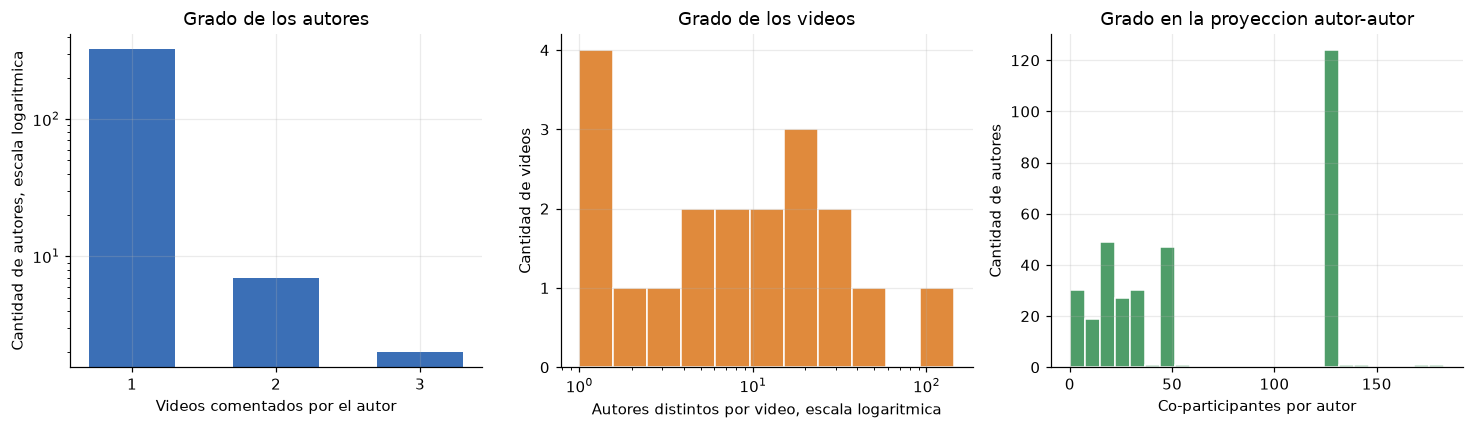

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))

axes[0].bar(*np.unique(grados_autor, return_counts=True), color=AZUL, width=0.6)
axes[0].set_yscale('log')
axes[0].set_xlabel('Videos comentados por el autor')
axes[0].set_ylabel('Cantidad de autores, escala logaritmica')
axes[0].set_title('Grado de los autores')
axes[0].set_xticks(sorted(np.unique(grados_autor)))

axes[1].hist(grados_video, bins=np.logspace(0, np.log10(grados_video.max()) + 0.05, 12), color=NARANJA,
             edgecolor='white')
axes[1].set_xscale('log')
axes[1].set_xlabel('Autores distintos por video, escala logaritmica')
axes[1].set_ylabel('Cantidad de videos')
axes[1].set_title('Grado de los videos')
axes[1].yaxis.get_major_locator().set_params(integer=True)

grados_pa_arr = np.array([d for _, d in P_autores.degree()])
axes[2].hist(grados_pa_arr, bins=25, color=VERDE, edgecolor='white')
axes[2].set_xlabel('Co-participantes por autor')
axes[2].set_ylabel('Cantidad de autores')
axes[2].set_title('Grado en la proyeccion autor-autor')

plt.show()

### 6.2 Cohesion y transitividad

La transitividad mide la proporcion de triangulos cerrados. En una red bipartita vale cero por
construccion, porque un triangulo necesitaria una arista entre dos nodos del mismo tipo y eso no
existe. Reportar ese cero como si fuera un hallazgo seria un error, asi que para la red bipartita
usamos el coeficiente de agrupamiento de Latapy, que mide el solapamiento entre los vecindarios de
nodos del mismo tipo.

Para la cohesion calculamos la conectividad de nodos y de aristas sobre la componente mayor, es
decir el minimo de elementos que habria que eliminar para desconectarla.

In [51]:
clustering_bip_autores = nx.bipartite.clustering(G, nodos_autor, mode='dot')
clustering_bip_videos = nx.bipartite.clustering(G, nodos_video, mode='dot')

print('Agrupamiento de Latapy en la red bipartita')
print(f'  autores: {np.mean(list(clustering_bip_autores.values())):.3f}')
print(f'  videos: {np.mean(list(clustering_bip_videos.values())):.3f}')
print(f'  transitividad clasica de la red bipartita: {nx.transitivity(G):.3f}, cero por construccion')
print()

componente_mayor = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print('Cohesion de la componente mayor de la red bipartita')
print('  nodos:', componente_mayor.number_of_nodes())
print('  conectividad de nodos:', nx.node_connectivity(componente_mayor))
print('  conectividad de aristas:', nx.edge_connectivity(componente_mayor))
print('  diametro:', nx.diameter(componente_mayor))
print('  longitud media de camino:', round(nx.average_shortest_path_length(componente_mayor), 2))
print()

componente_mayor_pa = P_autores.subgraph(max(nx.connected_components(P_autores), key=len)).copy()
print('Cohesion de la componente mayor de la proyeccion autor-autor')
print('  transitividad:', round(nx.transitivity(P_autores), 3))
print('  clustering medio:', round(nx.average_clustering(P_autores), 3))
print('  conectividad de nodos:', nx.node_connectivity(componente_mayor_pa))
print('  diametro:', nx.diameter(componente_mayor_pa))

Agrupamiento de Latapy en la red bipartita
  autores: 0.942
  videos: 0.014
  transitividad clasica de la red bipartita: 0.000, cero por construccion

Cohesion de la componente mayor de la red bipartita
  nodos: 286
  conectividad de nodos: 1
  conectividad de aristas: 1
  diametro: 12


  longitud media de camino: 4.72

Cohesion de la componente mayor de la proyeccion autor-autor
  transitividad: 0.984
  clustering medio: 0.972


  conectividad de nodos: 1
  diametro: 6


### 6.3 Nodos perifericos y aislados

In [52]:
componentes_bip = sorted(nx.connected_components(G), key=len, reverse=True)

print(f'La red bipartita tiene {len(componentes_bip)} componentes conexos.')
print()
resumen_componentes = pd.DataFrame([
    {
        'componente': i,
        'nodos': len(comp),
        'autores': sum(1 for n in comp if G.nodes[n]['tipo'] == 'autor'),
        'videos': sum(1 for n in comp if G.nodes[n]['tipo'] == 'video'),
        'canales': ', '.join(sorted({G.nodes[n]['canal'] for n in comp if G.nodes[n]['tipo'] == 'video'})),
    }
    for i, comp in enumerate(componentes_bip)
])
print(resumen_componentes.to_string(index=False, max_colwidth=60))

La red bipartita tiene 10 componentes conexos.

 componente  nodos  autores  videos                                                      canales
          0    286      276      10 Gobierno de la República de Guatemala, Noti7, PrensaLibre...
          1     26       25       1                                   Municipalidad de Guatemala
          2     19       18       1                                           Noticias Telemundo
          3      5        4       1                                                       Quorum
          4      4        3       1                                                       Quorum
          5      3        2       1                                Noticiero Guatevisión 13 Hrs.
          6      2        1       1                                                       Quorum
          7      2        1       1                                                       Quorum
          8      2        1       1                                            

In [53]:
print('Videos perifericos, con muy pocos autores distintos:')
perifericos = [(n, G.nodes[n]) for n in nodos_video if G.degree(n) <= 3]
for nodo, datos in sorted(perifericos, key=lambda x: G.degree(x[0])):
    print(f'  grado {G.degree(nodo)} | {datos["canal"]}: {datos["titulo"][:52]}')
print()
print('Nodos aislados en la red bipartita:', len(list(nx.isolates(G))))
print('Autores aislados en la proyeccion autor-autor:', len(list(nx.isolates(P_autores))))
for nodo in nx.isolates(P_autores):
    video = list(G.neighbors(nodo))[0]
    print(f'  {P_autores.nodes[nodo]["nombre"]}, unico comentarista de: {G.nodes[video]["titulo"][:45]}')

Videos perifericos, con muy pocos autores distintos:
  grado 1 | Quorum: Cruzando la ciudad a puro Transmetro
  grado 1 | Quorum: SHAI WA: la vecina queer de Casa Presidencial
  grado 1 | Quorum: ¿Quiénes pagan más en Centroamérica?
  grado 1 | Quorum: Edén por Salud: empleo inclusivo para personas con d
  grado 2 | Noticiero Guatevisión 13 Hrs.: Noticiero en Directo 1 pm, 28 de Agosto de 2026
  grado 3 | Quorum: 10 Preguntas a un año del Paro Nacional

Nodos aislados en la red bipartita: 0
Autores aislados en la proyeccion autor-autor: 4
  @jahirdiaz5862, unico comentarista de: ¿Quiénes pagan más en Centroamérica?
  @elizabethmonterroso7719, unico comentarista de: Cruzando la ciudad a puro Transmetro
  @elioelias7267, unico comentarista de: Edén por Salud: empleo inclusivo para persona
  @aditalissethevasquezrojas8039, unico comentarista de: SHAI WA: la vecina queer de Casa Presidencial


Hay que separar dos cosas que se parecen pero no son lo mismo.

El aislamiento observado si esta en el dato. En la red bipartita no existe ningun nodo de grado
cero, porque un autor solo entra a la red si comento y un video solo entra si recibio comentarios.
Lo que si existe son componentes separados: nueve videos no comparten ningun comentarista con
ningun otro video, y sus audiencias quedan como islas. En la proyeccion autor-autor aparecen
autores de grado cero, y todos son la misma situacion: fueron el unico comentarista de su video, de
modo que no coincidieron con nadie.

La ausencia de datos es un fenomeno distinto y mucho mas grande. Los 274 videos sin comentarios
recolectados no aparecen en ninguna de estas redes. No son videos aislados, son videos no
observados. Del mismo modo, un autor que aqui figura con un solo comentario pudo haber comentado en
decenas de videos que no entraron a la muestra. Todo lo que decimos sobre grado, componentes y
aislamiento describe la red observada y no la red real de participacion en YouTube.

### 6.4 Interpretacion de los hallazgos estructurales

La red bipartita tiene 351 nodos y 343 aristas. Con menos aristas que nodos, la estructura esta por
debajo del umbral de un arbol, lo que confirma que es un bosque de estrellas y no una malla. La
densidad bipartita ronda el cinco por ciento, es decir que de todos los pares autor-video posibles
solo se realiza uno de cada veinte.

La distribucion de grados es fuertemente asimetrica y en direcciones opuestas para cada tipo de
nodo. Del lado de los autores el 97.3 por ciento tiene grado uno, solo nueve superan ese valor y el
maximo es tres: un piso plano sin cola larga. Del lado de los videos el grado va de uno a 128 con
mediana siete, una distribucion con cola muy larga en la que el video mayor concentra el 37 por
ciento de todas las aristas. Respondiendo directamente a la pregunta del enunciado, las conexiones
estan concentradas en muy pocos nodos, y esos nodos son videos, no personas.

Los diez componentes conexos y la componente mayor con 286 nodos, el 81 por ciento del total,
resumen la fragmentacion. Esa componente mayor existe gracias a apenas siete autores puente que
enlazan diez videos. Es una integracion fragil, y en la seccion 8 verificamos que quitando esos
autores la red se parte.

La cohesion es minima: la conectividad de nodos y de aristas de la componente mayor es uno, lo que
significa que basta eliminar un solo nodo o una sola arista bien elegidos para desconectarla. El
diametro llega a doce y la longitud media de camino a 4.72, valores altos para una red de este
tamano, porque para ir de un autor a otro hay que pasar siempre por videos y por los pocos autores
puente.

Sobre la transitividad, la red bipartita da cero por construccion y el agrupamiento de Latapy da
0.942 para los autores frente a 0.014 para los videos. La asimetria es reveladora: los autores de un
mismo video comparten practicamente todo su vecindario porque casi ninguno comento en otro lado,
mientras que los videos casi no comparten audiencia entre si. En la proyeccion autor-autor la
transitividad sube a 0.984, pero eso tampoco es sociabilidad, es el resultado mecanico de convertir
cada video en un grupo completo. La conclusion honesta es que estas redes no muestran comunidades sociales cohesionadas,
muestran audiencias yuxtapuestas alrededor de piezas de contenido.

## 7. Comunidades

### 7.1 Eleccion de la red

Aplicamos la deteccion de comunidades sobre la red bipartita completa y no sobre las proyecciones,
por tres razones.

La proyeccion autor-autor no sirve para esto. Convierte a los comentaristas de cada video en un
grupo completamente conectado, asi que cualquier algoritmo de modularidad recuperaria esos grupos
por construccion y el resultado no aportaria informacion nueva. Ademas destruye la identidad de los
videos, que es justo lo que queremos ver dentro de cada comunidad.

La proyeccion video-video tiene apenas 19 nodos y 11 aristas. Detectar comunidades ahi equivale a
listar sus componentes conexos.

La red bipartita conserva los dos tipos de nodo, de modo que cada comunidad resultante contiene a la
vez videos y autores y se puede caracterizar por contenido y por publico al mismo tiempo. Como
control, al final aplicamos el mismo algoritmo sobre la proyeccion autor-autor y comparamos.

### 7.2 Algoritmo y supuestos

Usamos Louvain, implementado en networkx como louvain_communities. Es un metodo voraz que optimiza
la modularidad en dos fases repetidas: primero mueve cada nodo a la comunidad vecina que mas
aumenta la modularidad, y despues contrae cada comunidad en un supernodo y repite.

Los supuestos que hay que declarar son estos.

Louvain esta pensado para redes de un modo. Aplicado a una red bipartita, la modularidad se compara
contra un modelo nulo que permite aristas entre nodos del mismo tipo, aristas que aqui son
imposibles. Eso infla el valor de modularidad, asi que lo usamos como medida relativa de calidad y
no como una cifra absoluta comparable con la de otras redes.

El algoritmo es estocastico en el orden en que recorre los nodos, por eso fijamos la semilla y
ademas verificamos la estabilidad repitiendo la ejecucion con varias semillas.

Sobre los pesos, usamos el peso de la arista, que es la cantidad de comentarios del autor en ese
video. Un autor que comento seis veces en un video queda asi mas firmemente ligado a ese video que
uno que comento una sola vez. Como el 88 por ciento de las aristas tiene peso uno, el efecto es
pequeno, y lo comprobamos comparando la particion ponderada con la no ponderada.

El parametro de resolucion queda en uno, el valor por defecto, que no fuerza comunidades ni mas
grandes ni mas pequenas.

In [54]:
comunidades = nx.community.louvain_communities(G, weight='peso', seed=SEMILLA, resolution=1.0)
comunidades = sorted(comunidades, key=len, reverse=True)

modularidad = nx.community.modularity(G, comunidades, weight='peso')
comunidad_de = {nodo: i for i, comunidad in enumerate(comunidades) for nodo in comunidad}
nx.set_node_attributes(G, comunidad_de, 'comunidad')

print(f'Comunidades detectadas: {len(comunidades)}')
print(f'Modularidad ponderada: {modularidad:.3f}')
print()

# Estabilidad frente a la semilla y al uso de pesos.
for semilla in [0, 7, 42, 123, 2026]:
    particion = nx.community.louvain_communities(G, weight='peso', seed=semilla)
    print(f'  semilla {semilla:>4}: {len(particion)} comunidades, '
          f'modularidad {nx.community.modularity(G, particion, weight="peso"):.3f}')

sin_pesos = nx.community.louvain_communities(G, weight=None, seed=SEMILLA)
print(f'  sin usar pesos: {len(sin_pesos)} comunidades, '
      f'modularidad {nx.community.modularity(G, sin_pesos):.3f}')

Comunidades detectadas: 17
Modularidad ponderada: 0.777

  semilla    0: 17 comunidades, modularidad 0.777
  semilla    7: 17 comunidades, modularidad 0.777
  semilla   42: 17 comunidades, modularidad 0.777
  semilla  123: 17 comunidades, modularidad 0.777
  semilla 2026: 17 comunidades, modularidad 0.777
  sin usar pesos: 17 comunidades, modularidad 0.790


In [55]:
resumen_comunidades = pd.DataFrame([
    {
        'comunidad': i,
        'nodos': len(comunidad),
        'autores': sum(1 for n in comunidad if G.nodes[n]['tipo'] == 'autor'),
        'videos': sum(1 for n in comunidad if G.nodes[n]['tipo'] == 'video'),
        'comentarios': sum(G.nodes[n]['n_comentarios'] for n in comunidad if G.nodes[n]['tipo'] == 'video'),
        'canales': ', '.join(sorted({G.nodes[n]['canal'] for n in comunidad if G.nodes[n]['tipo'] == 'video'})),
    }
    for i, comunidad in enumerate(comunidades)
])

print('Tamano y composicion de cada comunidad:')
print(resumen_comunidades.to_string(index=False, max_colwidth=45))

Tamano y composicion de cada comunidad:
 comunidad  nodos  autores  videos  comentarios                               canales
         0    126      125       1          161                                Quorum
         1     48       47       1           50                                Quorum
         2     32       29       3           34                                Quorum
         3     31       30       1           45 Gobierno de la República de Guatemala
         4     26       25       1           25            Municipalidad de Guatemala
         5     19       18       1           25 Gobierno de la República de Guatemala
         6     19       18       1           25                    Noticias Telemundo
         7     14       13       1           14                                 Noti7
         8      8        7       1            7                        TN23 Guatemala
         9      8        7       1            7                    PrensaLibreOficial
        10    

In [56]:
comunidades_pa = nx.community.louvain_communities(P_autores, weight='weight', seed=SEMILLA)
print('Control sobre la proyeccion autor-autor')
print(f'  comunidades: {len(comunidades_pa)}')
print(f'  modularidad: {nx.community.modularity(P_autores, comunidades_pa, weight="weight"):.3f}')
print(f'  tamanos: {sorted((len(c) for c in comunidades_pa), reverse=True)}')

Control sobre la proyeccion autor-autor
  comunidades: 14
  modularidad: 0.395
  tamanos: [126, 61, 55, 28, 25, 18, 6, 4, 3, 2, 1, 1, 1, 1]


### 7.3 Numero de comunidades, tamanos y calidad

Louvain encuentra 17 comunidades con una modularidad ponderada de 0.777, un valor alto que indica
una particion muy limpia. Los tamanos van de 126 nodos a 2 nodos y la distribucion es muy desigual,
igual que todo lo demas en estos datos.

El resultado clave es que la particion coincide casi exactamente con los videos. Dieciseis de las 17
comunidades contienen un solo video con sus comentaristas, y solo una agrupa varios videos: la que
reune tres piezas de Quorum sobre servicios y ciudad. Esto no es una casualidad del
algoritmo sino una consecuencia directa de la estructura de estrellas descrita en la seccion 6.
Como casi nadie comenta en mas de un video, no hay forma de que una comunidad crezca mas alla de la
audiencia de un video, salvo cuando existen autores puente.

La particion es estable: con cinco semillas distintas el numero de comunidades y la modularidad se
mantienen practicamente iguales. Usar o no los pesos tampoco cambia la estructura, lo cual era
esperable porque 303 de las 343 aristas pesan uno.

El control sobre la proyeccion autor-autor da 14 comunidades y una modularidad mucho menor, de
0.395. La razon es que ahi los grupos de comentaristas ya estan completamente conectados y la
modularidad tiene poco margen para mejorar. Confirma que la red bipartita era la eleccion correcta.

Una advertencia sobre la lectura de estas comunidades: agrupan patrones de co-participacion, no
grupos sociales. Que dos personas caigan en la misma comunidad significa que comentaron el mismo
video, nada mas.

### 7.4 Visualizacion de todas las comunidades

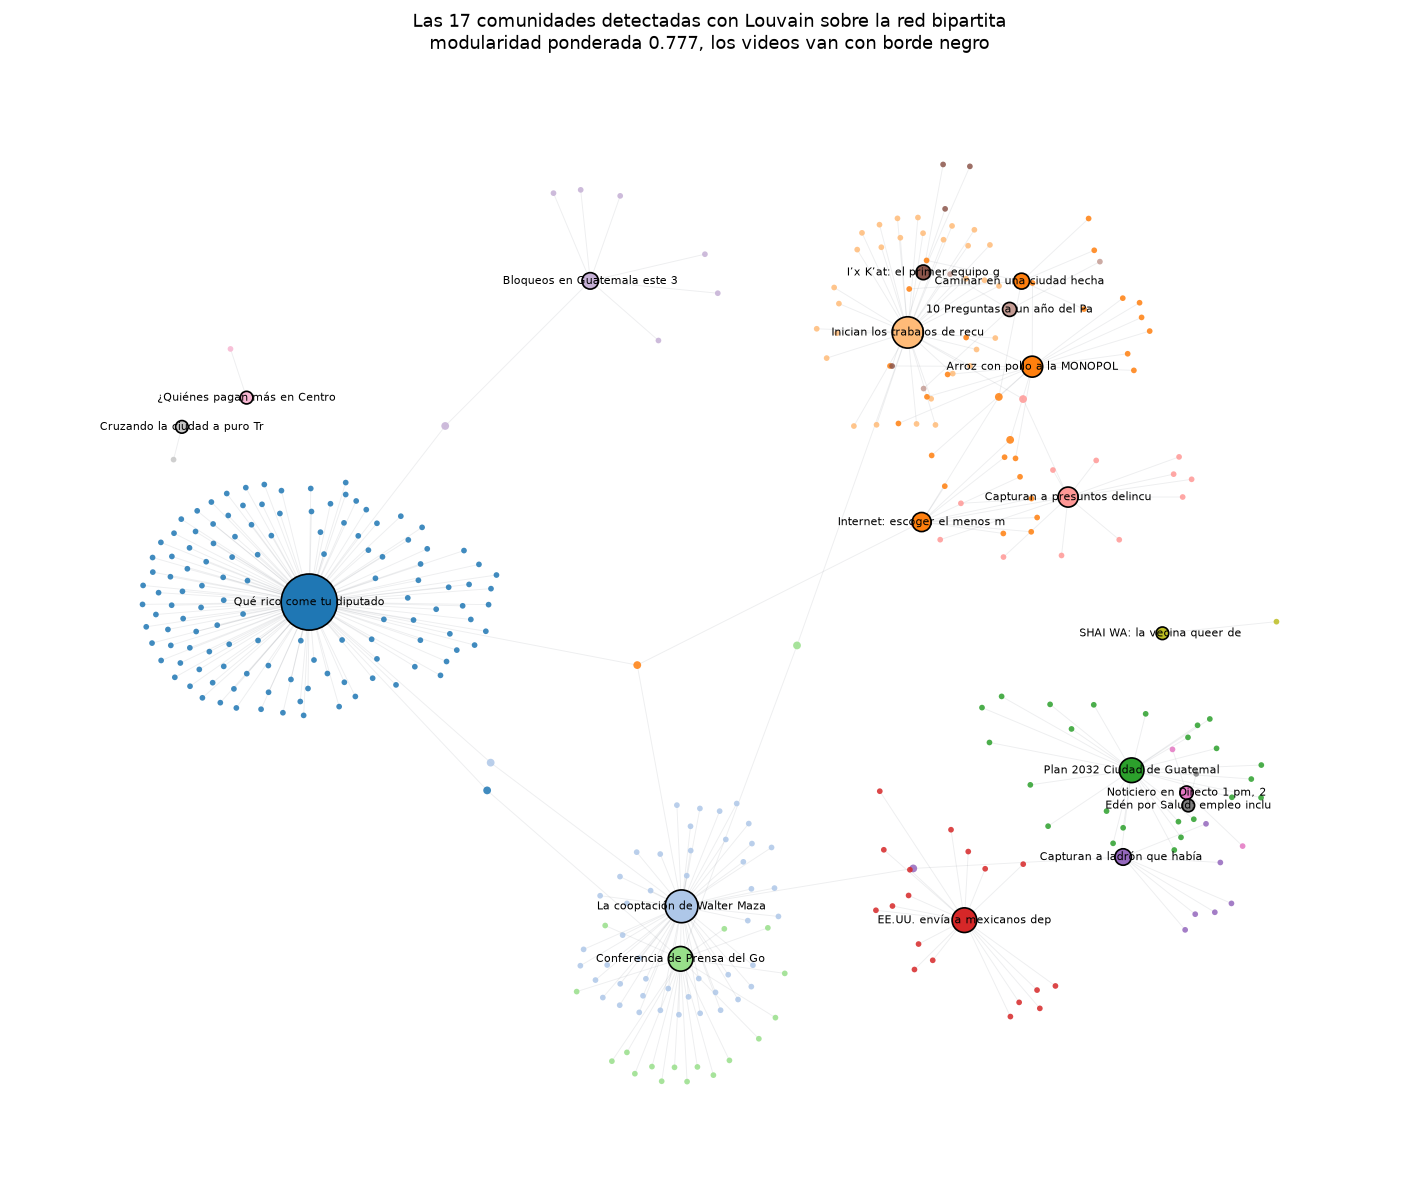

In [57]:
n_comunidades = len(comunidades)
mapa_colores = plt.cm.tab20(np.linspace(0, 1, 20))
color_comunidad = {i: mapa_colores[i % 20] for i in range(n_comunidades)}

fig, ax = plt.subplots(figsize=(13, 11))

nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.6, edge_color=GRIS, ax=ax)
nx.draw_networkx_nodes(
    G, pos, nodelist=nodos_autor,
    node_color=[color_comunidad[G.nodes[n]['comunidad']] for n in nodos_autor],
    node_size=[26 if G.degree(n) > 1 else 14 for n in nodos_autor],
    alpha=0.85, linewidths=0, ax=ax,
)
nx.draw_networkx_nodes(
    G, pos, nodelist=nodos_video,
    node_color=[color_comunidad[G.nodes[n]['comunidad']] for n in nodos_video],
    node_size=[60 + 8 * G.nodes[n]['n_comentarios'] for n in nodos_video],
    edgecolors='black', linewidths=1.1, ax=ax,
)
nx.draw_networkx_labels(G, pos, labels={n: G.nodes[n]['titulo'][:28] for n in nodos_video},
                        font_size=7.5, ax=ax)

ax.set_title(f'Las {n_comunidades} comunidades detectadas con Louvain sobre la red bipartita\n'
             f'modularidad ponderada {modularidad:.3f}, los videos van con borde negro')
ax.margins(0.06)
ax.axis('off')
ax.grid(False)
plt.show()

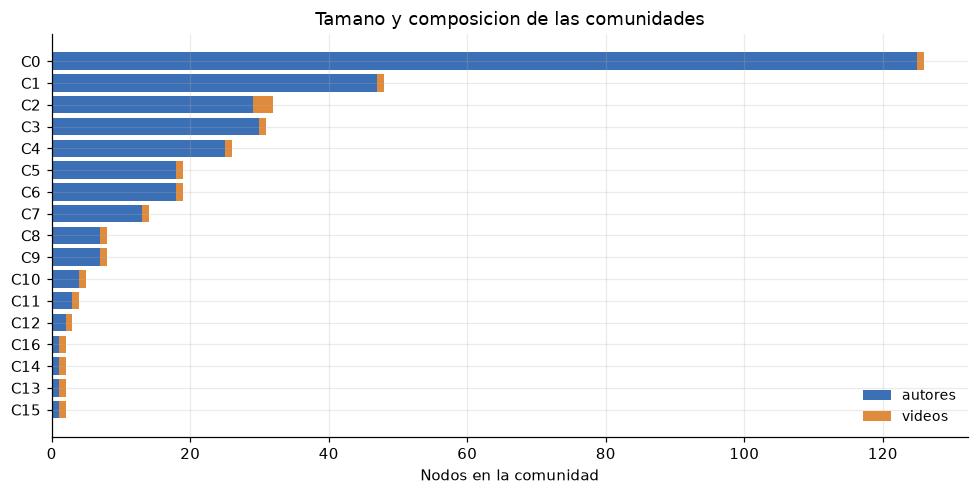

In [58]:
fig, ax = plt.subplots(figsize=(9, 4.6))

orden = resumen_comunidades.sort_values('nodos', ascending=True)
ax.barh([f'C{i}' for i in orden['comunidad']], orden['autores'], color=AZUL, label='autores')
ax.barh([f'C{i}' for i in orden['comunidad']], orden['videos'], left=orden['autores'],
        color=NARANJA, label='videos')
ax.set_xlabel('Nodos en la comunidad')
ax.set_title('Tamano y composicion de las comunidades')
ax.legend(frameon=False, fontsize=9)
plt.show()

### 7.5 Caracterizacion de las tres comunidades principales

In [59]:
comments['comunidad'] = comments['author_channel_id'].map(comunidad_de)


def caracterizar(indice, n_palabras=10, n_autores=4):
    comunidad = comunidades[indice]
    videos_com = [n for n in comunidad if G.nodes[n]['tipo'] == 'video']
    sub = comments[comments['video_id'].isin(videos_com)]

    print(f'===== Comunidad {indice} =====')
    print(f'nodos {len(comunidad)} | autores {len(comunidad) - len(videos_com)} | videos {len(videos_com)}')
    print(f'comentarios {len(sub)} | me gusta acumulados {int(sub["like_count"].sum())} | '
          f'respuestas {int(sub["reply_count"].sum())}')
    print('videos:')
    for v in sorted(videos_com, key=lambda n: -G.nodes[n]['n_comentarios']):
        d = G.nodes[v]
        print(f'  {d["n_comentarios"]:>4} comentarios | {d["vistas"]:>9,} vistas | {d["canal"]}: {d["titulo"][:50]}')
    print('canales:', dict(Counter(sub['channel_name'])))
    print('categorias:', dict(Counter(G.nodes[v]['categoria'] for v in videos_com)))
    intensidad = len(sub) / max(sub['author_channel_id'].nunique(), 1)
    print(f'intensidad de participacion: {intensidad:.2f} comentarios por autor')
    palabras = Counter(t for lista in sub['tokens'] for t in lista)
    print('palabras frecuentes:', [p for p, _ in palabras.most_common(n_palabras)])
    activos = sub.groupby('author_name').size().sort_values(ascending=False).head(n_autores)
    print('autores mas activos:', dict(activos))
    print()


for indice in range(3):
    caracterizar(indice)

===== Comunidad 0 =====
nodos 126 | autores 125 | videos 1
comentarios 161 | me gusta acumulados 358 | respuestas 3
videos:
   161 comentarios |    11,775 vistas | Quorum: Qué rico come tu diputado
canales: {'Quorum': 161}
categorias: {'News & Politics': 1}
intensidad de participacion: 1.26 comentarios por autor
palabras frecuentes: ['pueblo', 'diputado', 'pagar', 'dinero', 'trabajo', 'sueldo', 'almuerzo', 'trabajar', 'corrupto', 'ganar']
autores mas activos: {'@ManuelEdran': np.int64(5), '@ErvinLeonardoCarreraLatín': np.int64(4), '@HaroldoCastillo-rh9iw': np.int64(3), '@byronpontaza': np.int64(3)}

===== Comunidad 1 =====
nodos 48 | autores 47 | videos 1
comentarios 50 | me gusta acumulados 91 | respuestas 0
videos:
    50 comentarios |    10,156 vistas | Quorum: La cooptación de Walter Mazariegos en la USAC
canales: {'Quorum': 50}
categorias: {'News & Politics': 1}
intensidad de participacion: 1.02 comentarios por autor
palabras frecuentes: ['corrupto', 'usac', 'estudiante', 'univers

La comunidad 0 es la mas grande con 126 nodos y gira alrededor de un solo video de Quorum, Que rico
come tu diputado, con 161 comentarios y 125 de sus 128 comentaristas dentro de la comunidad. La
intensidad es de 1.26 comentarios por autor, o sea muchisima gente interviniendo una sola vez. El
vocabulario es inequivoco: pueblo, diputado, pagar, dinero, trabajo, sueldo, almuerzo y corrupto. Es
indignacion por el gasto publico de los legisladores. El sentimiento de esta comunidad se reporta en
el punto 9.2 y es el mas negativo de todo el conjunto.

La comunidad 1 tiene 48 nodos y corresponde al video de Quorum sobre la cooptacion de Walter
Mazariegos en la USAC. Su vocabulario mezcla el tema universitario, con usac, universidad,
estudiante, rector y csu, con el mismo eje politico de corrupcion y pacto. Aparece ademas un
componente de aprobacion hacia el trabajo periodistico, con palabras como excelente e informacion,
que la separa del tono puramente de queja de la comunidad 0.

La comunidad 2 es la mas interesante estructuralmente porque es la unica que agrupa tres videos
distintos, todos de Quorum: Internet escoger el menos malo, Arroz con pollo a la monopolio y Caminar
en una ciudad hecha para carros. Suma 34 comentarios de 29 autores, y lo que la mantiene unida es un
grupo pequeno de autores que comentaron en varios de esos videos, entre ellos el participante con
mas apariciones en videos distintos de todo el conjunto. Su vocabulario es economico y urbano, con
excelente, empresa, internet, ley, servicio y pais. Es la evidencia mas clara de una audiencia
tematica que sigue al canal mas alla de un video puntual.

Vale la pena mencionar una cuarta comunidad como contraste: la que corresponde al video Plan 2032
Ciudad de Guatemala de la Municipalidad. Tiene 25 comentarios de 25 autores distintos y es la unica
con tono claramente positivo, como se ve en la seccion 9.

## 8. Nodos centrales y participantes puente

### 8.1 Medidas de centralidad y por que estas

Calculamos cinco medidas sobre la red bipartita y las elegimos por lo que cada una responde en este
problema concreto.

Grado. Para un autor es en cuantos videos distintos participo y para un video es cuantos
comentaristas distintos atrajo. Es la medida mas directa de recurrencia y de alcance. La
acompanamos del grado ponderado, que suma comentarios en lugar de contactos.

Intermediacion. Cuenta en cuantos caminos mas cortos entre otros pares de nodos participa un nodo.
En esta red es la medida decisiva, porque identifica exactamente lo que el enunciado pide: quien
conecta contenidos que de otra forma quedarian separados. Un autor con intermediacion alta comento
en videos que no comparten publico con nadie mas.

Cercania. Mide que tan cerca esta un nodo del resto de la red. Sirve para distinguir a los autores
que estan en el centro estructural de los que estan en la periferia, y es una lectura util incluso
cuando el grado es identico.

PageRank. Reparte importancia siguiendo las aristas y respeta los pesos, asi que un autor que
comento varias veces en un video central recibe mas puntaje que uno que comento una vez. Lo
incluimos porque es la unica medida de nuestra lista que combina posicion e intensidad.

Centralidad de vector propio. Premia estar conectado a nodos que a su vez son importantes. La
reportamos con una advertencia: en una red casi desconectada y con estrellas dominantes tiende a
concentrarse casi por completo alrededor del nodo de mayor grado, asi que la usamos como
confirmacion y no como criterio principal.

Todas las medidas normalizadas se calculan sobre la red completa. Como la red no es conexa, la
cercania de networkx usa la correccion de Wasserman y Faust, que escala por el tamano de la
componente de cada nodo, de modo que los valores siguen siendo comparables entre nodos de
componentes distintos.

In [60]:
centralidades = pd.DataFrame({
    'grado': dict(G.degree()),
    'grado_ponderado': dict(G.degree(weight='peso')),
    'intermediacion': nx.betweenness_centrality(G, normalized=True),
    'cercania': nx.closeness_centrality(G, wf_improved=True),
    'pagerank': nx.pagerank(G, weight='peso'),
    'vector_propio': nx.eigenvector_centrality(G, max_iter=2000, tol=1e-08, weight='peso'),
})
centralidades['tipo'] = [G.nodes[n]['tipo'] for n in centralidades.index]
centralidades['etiqueta'] = [
    G.nodes[n]['nombre'] if G.nodes[n]['tipo'] == 'autor' else G.nodes[n]['titulo'][:42]
    for n in centralidades.index
]
centralidades['comunidad'] = [G.nodes[n]['comunidad'] for n in centralidades.index]

print('Correlacion de rango entre medidas, calculada por separado para cada tipo de nodo:')
for tipo in ['autor', 'video']:
    sub = centralidades[centralidades['tipo'] == tipo]
    print(f'\n{tipo}:')
    print(sub[['grado', 'intermediacion', 'cercania', 'pagerank', 'vector_propio']]
          .corr(method='spearman').round(2).to_string())

Correlacion de rango entre medidas, calculada por separado para cada tipo de nodo:

autor:
                grado  intermediacion  cercania  pagerank  vector_propio
grado            1.00            1.00      0.13      0.26           0.10
intermediacion   1.00            1.00      0.13      0.26           0.10
cercania         0.13            0.13      1.00     -0.18           0.98
pagerank         0.26            0.26     -0.18      1.00          -0.11
vector_propio    0.10            0.10      0.98     -0.11           1.00

video:
                grado  intermediacion  cercania  pagerank  vector_propio
grado            1.00            0.89      0.84      1.00           0.84
intermediacion   0.89            1.00      0.97      0.87           0.97
cercania         0.84            0.97      1.00      0.82           1.00
pagerank         1.00            0.87      0.82      1.00           0.82
vector_propio    0.84            0.97      1.00      0.82           1.00


### 8.2 Interpretacion separada para videos y para autores

In [61]:
columnas = ['etiqueta', 'grado', 'grado_ponderado', 'intermediacion', 'cercania', 'pagerank', 'vector_propio']

tabla_videos = centralidades[centralidades['tipo'] == 'video'].copy()
tabla_videos['canal'] = [G.nodes[n]['canal'] for n in tabla_videos.index]
tabla_videos = tabla_videos.sort_values('intermediacion', ascending=False)

print('Videos ordenados por intermediacion')
print(tabla_videos[['canal'] + columnas].round(4).to_string(index=False, max_colwidth=40))

Videos ordenados por intermediacion
                                canal                                 etiqueta  grado  grado_ponderado  intermediacion  cercania  pagerank  vector_propio
                               Quorum                Qué rico come tu diputado    128              161          0.5657    0.3046    0.1673         0.7070
Gobierno de la República de Guatemala Conferencia de Prensa del Gobierno de...     19               25          0.2440    0.2157    0.0249         0.0066
                               Quorum La cooptación de Walter Mazariegos en...     49               50          0.2275    0.2214    0.0632         0.0105
Gobierno de la República de Guatemala Inician los trabajos de recuperación ...     32               45          0.1876    0.1583    0.0426         0.0000
                               Quorum          Internet: escoger el menos malo     10               12          0.1283    0.2114    0.0133         0.0030
                               Quorum   

In [62]:
tabla_autores = centralidades[centralidades['tipo'] == 'autor'].copy()
tabla_autores['videos'] = [G.degree(n) for n in tabla_autores.index]
tabla_autores['comentarios'] = [G.nodes[n]['n_comentarios'] for n in tabla_autores.index]
tabla_autores['canales_distintos'] = [
    comments.loc[comments['author_channel_id'] == n, 'channel_id'].nunique() for n in tabla_autores.index
]

print('Autores mas centrales por intermediacion, es decir los puentes:')
print(tabla_autores.sort_values('intermediacion', ascending=False)
      .head(10)[['etiqueta', 'videos', 'canales_distintos', 'comentarios', 'intermediacion', 'cercania', 'pagerank']]
      .round(4).to_string(index=False))
print()
print('Autores mas recurrentes por cantidad de comentarios:')
print(tabla_autores.sort_values(['comentarios', 'videos'], ascending=False)
      .head(10)[['etiqueta', 'videos', 'canales_distintos', 'comentarios', 'intermediacion', 'pagerank']]
      .round(4).to_string(index=False))

Autores mas centrales por intermediacion, es decir los puentes:
               etiqueta  videos  canales_distintos  comentarios  intermediacion  cercania  pagerank
    @virgiliogarcia3039       2                  2            3          0.2316    0.2528    0.0030
         @inge_vergueta       3                  1            3          0.2181    0.2655    0.0033
           @josegil3813       2                  1            2          0.1768    0.1827    0.0021
           @Jel.Awesh.M       2                  1            3          0.0892    0.2479    0.0035
          @hashojea7348       3                  1            4          0.0597    0.1732    0.0045
   @franciscoflores3120       2                  2            2          0.0579    0.1346    0.0023
        @Alejandro00710       2                  1            2          0.0323    0.1717    0.0025
     @MarcosCarillo-b1r       2                  2            2          0.0319    0.1761    0.0027
      @moisesvaldez4043       2     

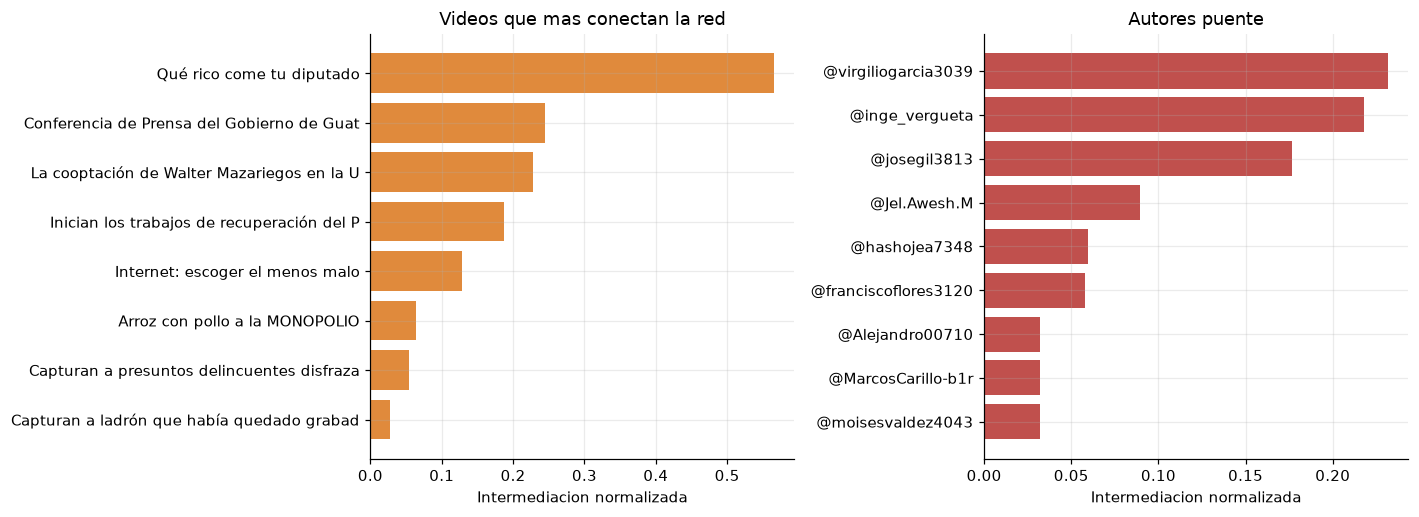

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

top_v = tabla_videos.head(8)[::-1]
axes[0].barh(top_v['etiqueta'], top_v['intermediacion'], color=NARANJA)
axes[0].set_xlabel('Intermediacion normalizada')
axes[0].set_title('Videos que mas conectan la red')

top_a = tabla_autores.sort_values('intermediacion', ascending=False).head(9)[::-1]
axes[1].barh(top_a['etiqueta'], top_a['intermediacion'], color=ROJO)
axes[1].set_xlabel('Intermediacion normalizada')
axes[1].set_title('Autores puente')

plt.show()

Para los videos, el alcance y la capacidad de conectar audiencias no son lo mismo. El video Que
rico come tu diputado domina las dos cosas, con 128 comentaristas distintos y la intermediacion mas
alta de la red, pero el segundo lugar en intermediacion lo ocupa la conferencia de prensa del
Gobierno, que tiene apenas 19 comentaristas. Su posicion no viene del tamano sino de estar en el
camino que une dos zonas de la red que de otro modo estarian separadas. En el otro extremo, videos
con audiencias respetables como el Plan 2032 de la Municipalidad, con 25 comentaristas, o el de
Noticias Telemundo, con 18, tienen intermediacion practicamente nula: su publico no se solapa con el
de nadie mas, asi que casi ningun camino pasa por ellos.

Para los autores el panorama es distinto. Ningun autor supera grado tres y sus valores de grado
apenas se diferencian, de modo que el grado no discrimina. La intermediacion si lo hace y separa con
claridad a nueve autores del resto de los 332. Los dos primeros son los que sostienen la
integracion de la red: comentaron en dos o tres videos que ningun otro autor visita en conjunto.

Vale la pena separar recurrencia de diversidad, porque no coinciden. Los dos autores con mas
comentarios de todo el conjunto escribieron seis cada uno, pero todos en un mismo video, asi que su
intermediacion es cero: son intensos pero no conectan nada. Los autores puente, en cambio, escribieron dos o tres comentarios
en total y estan repartidos en videos distintos. En terminos de estructura, la diversidad de
participacion importa mucho mas que el volumen.

La correlacion de rango entre medidas confirma la lectura y muestra que cada una aporta algo
distinto. Para los videos, grado y PageRank son practicamente la misma medida, con correlacion uno,
mientras que la intermediacion se separa un poco y la cercania se acerca mas a la intermediacion que
al grado. Para los autores, grado e intermediacion coinciden por completo, porque comentar en mas
videos es lo unico que produce caminos, mientras que el PageRank apenas correlaciona 0.26 con ellas
y ordena por intensidad de participacion en vez de por posicion. La centralidad de vector propio se
concentra casi por completo alrededor del video mas grande, que se lleva 0.71 de un maximo de uno
mientras el resto queda cerca de cero, tal como habiamos anticipado, asi que no la usamos para
ordenar.

### 8.3 Participantes recurrentes, autores puente y videos articuladores

Un nodo de articulacion es aquel cuya eliminacion aumenta el numero de componentes conexos. Es la
definicion formal de nodo cuya perdida segmenta la red, asi que la usamos para responder la
pregunta directamente en lugar de conformarnos con el ranking de intermediacion.

In [64]:
articuladores = list(nx.articulation_points(G))
articuladores_video = [n for n in articuladores if G.nodes[n]['tipo'] == 'video']
articuladores_autor = [n for n in articuladores if G.nodes[n]['tipo'] == 'autor']

componentes_base = nx.number_connected_components(G)
mayor_base = len(max(nx.connected_components(G), key=len))

print(f'Nodos de articulacion: {len(articuladores)}, de los cuales {len(articuladores_video)} videos '
      f'y {len(articuladores_autor)} autores.')
print(f'Situacion de partida: {componentes_base} componentes, la mayor con {mayor_base} nodos.')
print()

filas = []
for nodo in articuladores_autor:
    H = G.copy()
    H.remove_node(nodo)
    filas.append({
        'autor': G.nodes[nodo]['nombre'],
        'videos_comentados': G.degree(nodo),
        'comentarios': G.nodes[nodo]['n_comentarios'],
        'componentes_tras_quitarlo': nx.number_connected_components(H),
        'mayor_componente': len(max(nx.connected_components(H), key=len)),
        'nodos_desprendidos': mayor_base - len(max(nx.connected_components(H), key=len)) - 1,
    })

efecto_autores = pd.DataFrame(filas).sort_values('nodos_desprendidos', ascending=False)
print('Efecto de eliminar cada autor articulador:')
print(efecto_autores.to_string(index=False))

Nodos de articulacion: 22, de los cuales 15 videos y 7 autores.
Situacion de partida: 10 componentes, la mayor con 286 nodos.

Efecto de eliminar cada autor articulador:
               autor  videos_comentados  comentarios  componentes_tras_quitarlo  mayor_componente  nodos_desprendidos
 @virgiliogarcia3039                  2            3                         11               221                  64
        @josegil3813                  2            2                         11               240                  45
      @inge_vergueta                  3            3                         11               254                  31
@franciscoflores3120                  2            2                         11               272                  13
  @MarcosCarillo-b1r                  2            2                         11               278                   7
   @moisesvaldez4043                  2            2                         11               278                   7
    

In [65]:
H = G.copy()
H.remove_nodes_from(articuladores_autor)
print('Efecto de eliminar simultaneamente a los siete autores articuladores:')
print(f'  componentes: {componentes_base} pasa a {nx.number_connected_components(H)}')
print(f'  mayor componente: {mayor_base} pasa a {len(max(nx.connected_components(H), key=len))} nodos')
print()

print('Videos articuladores, ordenados por comentaristas:')
for nodo in sorted(articuladores_video, key=lambda n: -G.degree(n)):
    d = G.nodes[nodo]
    print(f'  grado {G.degree(nodo):>3} | {d["canal"]}: {d["titulo"][:52]}')
print()

recurrentes = tabla_autores[tabla_autores['comentarios'] > 1].sort_values('comentarios', ascending=False)
print(f'Participantes recurrentes, con mas de un comentario: {len(recurrentes)} de {len(tabla_autores)} autores.')
print(recurrentes.head(8)[['etiqueta', 'comentarios', 'videos', 'intermediacion']].round(4).to_string(index=False))

Efecto de eliminar simultaneamente a los siete autores articuladores:
  componentes: 10 pasa a 17
  mayor componente: 286 pasa a 173 nodos

Videos articuladores, ordenados por comentaristas:
  grado 128 | Quorum: Qué rico come tu diputado
  grado  49 | Quorum: La cooptación de Walter Mazariegos en la USAC
  grado  32 | Gobierno de la República de Guatemala: Inician los trabajos de recuperación del Puente Beli
  grado  25 | Municipalidad de Guatemala: Plan 2032 Ciudad de Guatemala
  grado  19 | Gobierno de la República de Guatemala: Conferencia de Prensa del Gobierno de Guatemala. #La
  grado  18 | Noticias Telemundo: EE.UU. envía a mexicanos deportados a Guatemala ante
  grado  16 | Quorum: Arroz con pollo a la MONOPOLIO
  grado  13 | Noti7: Capturan a presuntos delincuentes disfrazados de muj
  grado  10 | Quorum: Internet: escoger el menos malo
  grado   7 | TN23 Guatemala: Capturan a ladrón que había quedado grabado mientras
  grado   7 | PrensaLibreOficial: Bloqueos en Guatemala es

La red tiene 22 nodos de articulacion, 15 videos y 7 autores.

Que casi todos los videos sean articuladores es una consecuencia directa de la forma de estrella:
al quitar un video, sus comentaristas exclusivos quedan sueltos. Es informacion util pero
estructuralmente trivial.

Los siete autores articuladores son el hallazgo real. Son las unicas personas que sostienen la
integracion entre audiencias de videos distintos, y su efecto es desproporcionado respecto a su
actividad. Eliminando a uno solo de ellos la red pasa de diez a once componentes, y en el caso
extremo la componente mayor cae de 286 a 221 nodos, es decir se desprenden 64. Eliminando a los
siete a la vez la red pasa de diez a diecisiete componentes y la componente mayor se reduce de 286 a
173 nodos, una perdida del 40 por ciento. Son personas que escribieron entre dos y cuatro
comentarios en total.

Esto separa con claridad dos figuras que suelen confundirse. El participante recurrente comenta
mucho, casi siempre en el mismo video, y aporta volumen de conversacion pero no conectividad. Los
dos autores con mas comentarios del conjunto escribieron seis cada uno, ambos concentrados en un
solo video, y su intermediacion es exactamente cero. El autor puente comenta poco pero en lugares
distintos, y es el unico que aporta estructura. En esta red hay 46 recurrentes y solo 9 puentes, de
los cuales 7 son criticos.

Una precaucion final. Estos siete autores son criticos en la red observada, no necesariamente en la
participacion real. Si la recoleccion hubiera cubierto los otros 274 videos, es muy probable que
aparecieran muchos mas solapamientos y que ninguna persona individual resultara tan determinante.
La fragilidad que medimos es en buena parte fragilidad de la muestra.

## 9. Analisis de contenido y sentimiento

### 9.1 Modelo elegido y justificacion

Usamos pysentimiento con el modelo de sentimiento en espanol, que es un RoBERTuito afinado sobre el
corpus TASS de tweets en espanol y clasifica cada texto en positivo, negativo o neutro devolviendo
ademas la probabilidad de cada clase.

Descartamos las alternativas por razones concretas. VADER y TextBlob estan construidos para ingles,
y aplicarlos a comentarios en espanol guatemalteco produce resultados sin sentido. Un lexico
traducido pierde la negacion, la ironia y el modismo local, que son abundantes en este corpus. Un
modelo transformer entrenado sobre texto real de redes sociales en espanol maneja mucho mejor la
puntuacion expresiva, las mayusculas enfaticas, los emojis y las expresiones coloquiales.

Dos decisiones metodologicas importantes. Primero, el analisis corre sobre texto_original y no
sobre texto_limpio: el modelo aprovecha justamente los emojis, la puntuacion y las mayusculas que
la limpieza elimina, y quitar las stopwords borraria las negaciones, que son decisivas para el
sentimiento. Segundo, en lugar de quedarnos solo con la etiqueta ganadora construimos un puntaje
continuo restando la probabilidad negativa a la positiva. Ese puntaje va de menos uno a uno,
permite promediar por grupo y refleja la intensidad, no solo la direccion.

Como toda herramienta automatica, el modelo tiene margen de error, sobre todo con ironia y con
comentarios muy cortos. Por eso mostramos ejemplos concretos junto a las metricas agregadas.

In [66]:
from pysentimiento import create_analyzer

analizador = create_analyzer(task='sentiment', lang='es')
predicciones = analizador.predict(comments['texto_original'].tolist())

comments['sentimiento'] = [p.output for p in predicciones]
comments['prob_positivo'] = [p.probas['POS'] for p in predicciones]
comments['prob_negativo'] = [p.probas['NEG'] for p in predicciones]
comments['prob_neutro'] = [p.probas['NEU'] for p in predicciones]
comments['puntaje_sentimiento'] = comments['prob_positivo'] - comments['prob_negativo']

distribucion = comments['sentimiento'].value_counts()
print('Distribucion de sentimiento en los 406 comentarios:')
print(pd.DataFrame({
    'comentarios': distribucion,
    'porcentaje': (distribucion / len(comments) * 100).round(1),
}).to_string())
print()
print(f'Puntaje medio global: {comments["puntaje_sentimiento"].mean():.3f}')
print(f'Confianza media de la clase ganadora: '
      f'{comments[["prob_positivo", "prob_negativo", "prob_neutro"]].max(axis=1).mean():.3f}')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Distribucion de sentimiento en los 406 comentarios:
             comentarios  porcentaje
sentimiento                         
NEG                  250        61.6
POS                   80        19.7
NEU                   76        18.7

Puntaje medio global: -0.377
Confianza media de la clase ganadora: 0.812


In [67]:
print('Comentarios clasificados como mas negativos:')
for texto in comments.nsmallest(4, 'puntaje_sentimiento')['texto_original']:
    print('  -', str(texto)[:120].replace(chr(10), ' '))
print()
print('Comentarios clasificados como mas positivos:')
for texto in comments.nlargest(4, 'puntaje_sentimiento')['texto_original']:
    print('  -', str(texto)[:120].replace(chr(10), ' '))
print()
print('Comentarios clasificados como neutros:')
for texto in comments.nlargest(4, 'prob_neutro')['texto_original']:
    print('  -', str(texto)[:120].replace(chr(10), ' '))

Comentarios clasificados como mas negativos:
  - Que indignante saber como se artan estos coches y finalmente el pueblo esta ciendo dañado
  - Ni el mismo lo cree, estos son sinverguenzas y se pasan de pija, cómo se sentirá la familia tener a alguien mañoso, mafi
  - Y solo con esta información nos damos con la realidad del CACIF y sus intereses, estamos jodidos si no hacemos algo.
  - Que pena! Que la administración de Trump no ofrezca AMNISTÍA a los mexicanos u otros grupos de personas trabajadoras que

Comentarios clasificados como mas positivos:
  - Es un proyecto extraordinario , vamos adelante mi guate hermosa!
  - Que bueno que Guatemala sea una cuidad bonita y ojalá todos los proyectos sean realidad. Se los deseo con todo corazón d
  - Se ve moderna Y bella la ciudad de Guatemala .......Saludos desde Ecuador
  - Gracias por este video, que importante conocer este tipo de espacios.

Comentarios clasificados como neutros:
  - Pregúntenle si se acuerda de la marca del vino que se 

### 9.2 Comparacion por video, canal y comunidad

In [68]:
sentimiento_canal = comments.groupby('channel_name').agg(
    comentarios=('comment_id', 'size'),
    puntaje=('puntaje_sentimiento', 'mean'),
    pct_negativo=('sentimiento', lambda s: (s == 'NEG').mean() * 100),
    pct_positivo=('sentimiento', lambda s: (s == 'POS').mean() * 100),
    likes_promedio=('like_count', 'mean'),
).sort_values('puntaje')

print('Sentimiento por canal, solo canales con al menos 5 comentarios:')
print(sentimiento_canal[sentimiento_canal['comentarios'] >= 5].round(2).to_string())

Sentimiento por canal, solo canales con al menos 5 comentarios:
                                       comentarios  puntaje  pct_negativo  pct_positivo  likes_promedio
channel_name                                                                                           
PrensaLibreOficial                               7    -0.76         85.71          0.00            0.14
TN23 Guatemala                                   7    -0.62         85.71          0.00            0.00
Quorum                                         256    -0.50         70.31         14.45            1.88
Noticias Telemundo                              25    -0.46         64.00         12.00            1.00
Gobierno de la República de Guatemala           70    -0.22         50.00         24.29            1.57
Noti7                                           14    -0.18         28.57         21.43            0.86
Municipalidad de Guatemala                      25     0.61          8.00         80.00           67.88


In [69]:
sentimiento_video = (
    comments.groupby('video_id').agg(
        comentarios=('comment_id', 'size'),
        autores=('author_channel_id', 'nunique'),
        puntaje=('puntaje_sentimiento', 'mean'),
        pct_negativo=('sentimiento', lambda s: (s == 'NEG').mean() * 100),
        pct_positivo=('sentimiento', lambda s: (s == 'POS').mean() * 100),
    )
    .merge(videos[['video_id', 'title', 'channel_name']].set_index('video_id'), left_index=True, right_index=True)
    .sort_values('puntaje')
)

print('Sentimiento por video, solo videos con al menos 5 comentarios:')
print(sentimiento_video[sentimiento_video['comentarios'] >= 5]
      [['channel_name', 'title', 'comentarios', 'puntaje', 'pct_negativo', 'pct_positivo']]
      .round(2).to_string(index=False, max_colwidth=42))

Sentimiento por video, solo videos con al menos 5 comentarios:
                         channel_name                                      title  comentarios  puntaje  pct_negativo  pct_positivo
                   PrensaLibreOficial Bloqueos en Guatemala este 31 de agosto...            7    -0.76         85.71          0.00
                               Quorum                  Qué rico come tu diputado          161    -0.67         81.37          5.59
                       TN23 Guatemala Capturan a ladrón que había quedado gra...            7    -0.62         85.71          0.00
                               Quorum    Caminar en una ciudad hecha para carros            6    -0.54         66.67          0.00
                   Noticias Telemundo EE.UU. envía a mexicanos deportados a G...           25    -0.46         64.00         12.00
Gobierno de la República de Guatemala Conferencia de Prensa del Gobierno de G...           25    -0.42         68.00         16.00
                    

In [70]:
sentimiento_comunidad = comments.groupby('comunidad').agg(
    comentarios=('comment_id', 'size'),
    autores=('author_channel_id', 'nunique'),
    puntaje=('puntaje_sentimiento', 'mean'),
    pct_negativo=('sentimiento', lambda s: (s == 'NEG').mean() * 100),
    pct_positivo=('sentimiento', lambda s: (s == 'POS').mean() * 100),
).sort_values('comentarios', ascending=False)

sentimiento_comunidad['canales'] = [
    ', '.join(sorted({G.nodes[n]['canal'] for n in comunidades[int(i)] if G.nodes[n]['tipo'] == 'video'}))
    for i in sentimiento_comunidad.index
]

print('Sentimiento por comunidad detectada en la seccion 7:')
print(sentimiento_comunidad[sentimiento_comunidad['comentarios'] >= 5]
      .round(2).to_string(max_colwidth=42))

Sentimiento por comunidad detectada en la seccion 7:
           comentarios  autores  puntaje  pct_negativo  pct_positivo                                canales
comunidad                                                                                                  
0                  159      125    -0.67         81.13          5.66                                 Quorum
1                   49       47    -0.35         59.18         20.41                                 Quorum
3                   43       30    -0.09         39.53         30.23  Gobierno de la República de Guatemala
2                   36       29    -0.21         50.00         27.78                                 Quorum
4                   25       25     0.61          8.00         80.00             Municipalidad de Guatemala
5                   25       18    -0.43         68.00         16.00  Gobierno de la República de Guatemala
6                   25       18    -0.46         64.00         12.00               

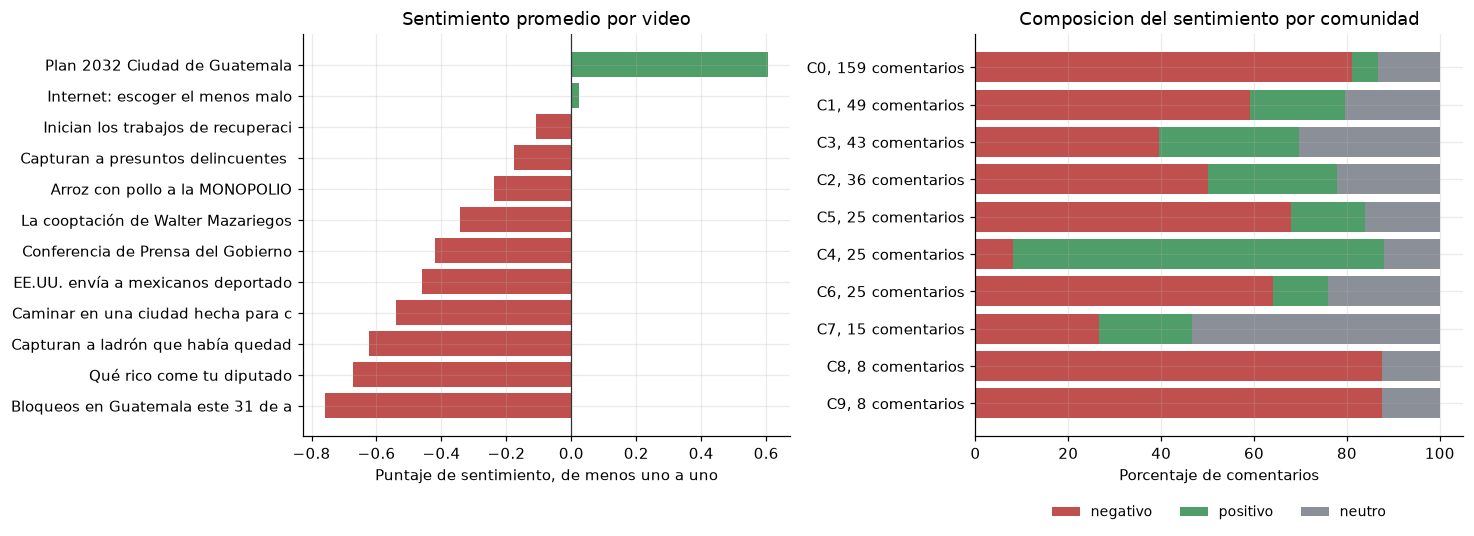

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

datos_video = sentimiento_video[sentimiento_video['comentarios'] >= 5]
etiquetas_v = [t[:34] for t in datos_video['title']]
colores_barras = [VERDE if p > 0 else ROJO for p in datos_video['puntaje']]
axes[0].barh(etiquetas_v, datos_video['puntaje'], color=colores_barras)
axes[0].axvline(0, color='#333', linewidth=0.8)
axes[0].set_xlabel('Puntaje de sentimiento, de menos uno a uno')
axes[0].set_title('Sentimiento promedio por video')

datos_com = sentimiento_comunidad[sentimiento_comunidad['comentarios'] >= 5].sort_values('comentarios')
etiquetas_c = [f'C{int(i)}, {int(n)} comentarios' for i, n in
               zip(datos_com.index, datos_com['comentarios'])]
abajo = np.zeros(len(datos_com))
for columna, color, nombre in [('pct_negativo', ROJO, 'negativo'), ('pct_positivo', VERDE, 'positivo')]:
    axes[1].barh(etiquetas_c, datos_com[columna], left=abajo, color=color, label=nombre)
    abajo = abajo + datos_com[columna].values
axes[1].barh(etiquetas_c, 100 - abajo, left=abajo, color=GRIS, label='neutro')
axes[1].set_xlabel('Porcentaje de comentarios')
axes[1].set_title('Composicion del sentimiento por comunidad')
axes[1].legend(frameon=False, fontsize=9, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.14))

plt.show()

In [72]:
print('Relacion entre sentimiento y reconocimiento del comentario:')
print(comments.groupby('sentimiento').agg(
    comentarios=('comment_id', 'size'),
    likes_promedio=('like_count', 'mean'),
    likes_mediana=('like_count', 'median'),
    likes_totales=('like_count', 'sum'),
    respuestas_promedio=('reply_count', 'mean'),
).round(2).to_string())
print()
print(f'Correlacion de Spearman entre puntaje de sentimiento y me gusta: '
      f'{comments["puntaje_sentimiento"].corr(comments["like_count"], method="spearman"):.2f}')
print()
print('Palabras mas frecuentes segun la clase de sentimiento:')
for clase in ['NEG', 'NEU', 'POS']:
    sub = comments[comments['sentimiento'] == clase]
    palabras = Counter(t for lista in sub['tokens'] for t in lista)
    print(f'  {clase}: {[p for p, _ in palabras.most_common(12)]}')

Relacion entre sentimiento y reconocimiento del comentario:
             comentarios  likes_promedio  likes_mediana  likes_totales  respuestas_promedio
sentimiento                                                                                
NEG                  250            1.67            0.0            418                 0.11
NEU                   76            7.45            1.0            566                 0.09
POS                   80           16.76            2.0           1341                 0.21

Correlacion de Spearman entre puntaje de sentimiento y me gusta: 0.23

Palabras mas frecuentes segun la clase de sentimiento:
  NEG: ['pueblo', 'diputado', 'pagar', 'dinero', 'corrupto', 'país', 'guatemala', 'empresa', 'seguir', 'pais', 'sueldo', 'trabajo']
  NEU: ['excelente', 'guatemala', 'presidente', 'bernardo', 'arevalo', 'apoyo', 'persona', 'regresar', 'usac', 'nombre', 'trabajo', 'vivo']
  POS: ['guatemala', 'excelente', 'presidente', 'vivir', 'trabajo', 'proyecto', '

### 9.3 Hallazgos de contenido y sentimiento

El tono general es marcadamente negativo. El 62 por ciento de los comentarios se clasifica como
negativo, el 20 por ciento como positivo y el 19 por ciento como neutro, con un puntaje medio de
menos 0.38. Esto no describe a los usuarios de YouTube sino al tipo de contenido que entro a la
muestra: videos de noticias, corrupcion, capturas policiales y gestion publica en Guatemala.

La variacion entre canales es grande y coherente con el contenido. Prensa Libre y TN23, ambos con
notas sobre bloqueos y delincuencia, son los mas negativos. Quorum, que concentra el 63 por ciento
de los comentarios, tiene un puntaje muy negativo empujado sobre todo por el video del gasto de los
diputados. El canal del Gobierno queda en una posicion intermedia, con casi un 25 por ciento de
comentarios positivos junto a criticas. Y hay una excepcion clara: la Municipalidad de Guatemala es
el unico canal con puntaje positivo, con 80 por ciento de comentarios favorables en el video del
Plan 2032. Es contenido de proyecto urbano a futuro, no de conflicto.

Al bajar al nivel de comunidad, la comunidad 0 es la mas negativa de todas, con mas del 80 por
ciento de comentarios negativos y un vocabulario de dinero, sueldo, hambre y corrupto. La comunidad
1, sobre la USAC, es negativa pero menos, con 59 por ciento de negativos y 20 de positivos, y mezcla
la critica politica con reconocimiento explicito al trabajo periodistico. La comunidad 2, la unica
que agrupa varios videos, es la mas equilibrada de las tres grandes: 50 por ciento de negativos
frente a 28 de positivos, con un vocabulario argumentativo sobre empresas, internet, ley y
servicios. Es decir, la comunidad estructuralmente mas conectada es tambien la de tono menos
crispado, aunque siga siendo mayoritariamente critica.

Un hallazgo que no esperabamos es la relacion entre sentimiento y reconocimiento. Los comentarios
positivos reciben en promedio diez veces mas me gusta que los negativos, y concentran mas de la
mitad de todos los me gusta del conjunto pese a ser solo el 20 por ciento de los comentarios. La
correlacion de rangos entre puntaje y me gusta es positiva pero moderada, 0.23. Hay que leerlo con
cuidado: es una asociacion dentro de esta muestra, no evidencia de que el publico premie la
positividad en general, y esta confundida con el canal, porque el video con mas me gusta positivos
es tambien el unico de tono celebratorio.

El vocabulario por clase cierra el cuadro. En los negativos dominan pueblo, diputado, pagar, dinero
y corrupto. En los positivos aparecen guatemala, excelente, vivir, proyecto, ciudad y saludo, es
decir celebracion y agradecimiento. En los neutros predominan terminos descriptivos y nombres
propios como presidente, bernardo, arevalo y usac, lo que corresponde a comentarios informativos o
preguntas. Las tres listas son consistentes con la lectura
manual de los ejemplos, lo que da confianza en la clasificacion automatica.

## 10. Interpretacion, limitaciones y conclusiones

### 10.1 Los hallazgos en el contexto de la participacion en YouTube

Lo que estas redes describen no es una comunidad conversando sino un publico distribuido alrededor
de piezas de contenido. La estructura de estrellas dominante, con el 97 por ciento de los autores
conectados a un solo video, corresponde a un patron de consumo en el que la persona llega a un
video, deja una opinion y no vuelve. Los 406 comentarios provienen de 332 personas distintas, es
decir 1.2 comentarios por persona.

Esto tiene una consecuencia directa para la nocion de comunidad. Las 17 comunidades que detecta
Louvain coinciden casi exactamente con los videos, no porque el algoritmo falle sino porque en
estos datos la unidad de agregacion social efectiva es el video y no el grupo de personas. La
audiencia se organiza alrededor del contenido, no alrededor de vinculos entre usuarios.

La participacion y la visibilidad son fenomenos distintos. El video mas visto de la muestra
comentada, con 304 mil vistas, es el que menos conversacion genera por vista, con 0.08 comentarios
por cada mil vistas, mientras que varios videos de menos de dos mil vistas superan los 13, mas de
cien veces esa tasa. Lo que parece movilizar comentarios es el tema, sobre todo cuando toca dinero publico y
figuras politicas, y no el alcance bruto.

La integracion de todo el sistema descansa en muy pocas personas. Siete autores que escribieron
entre dos y cuatro comentarios cada uno son los unicos que conectan audiencias de videos distintos,
y sin ellos la red se fragmenta. Es un recordatorio de que en redes de co-participacion la relevancia
estructural no coincide con el volumen de actividad.

Finalmente, el contenido y la estructura se refuerzan. La comunidad mas grande es tambien la mas
negativa, y la unica comunidad que agrupa varios videos es la de tono mas argumentativo. La
audiencia que circula entre contenidos es distinta de la que reacciona a un video puntual.

### 10.2 Limitaciones

Cobertura de comentarios. Es la limitacion mas seria. Solo 19 de los 293 videos tienen comentarios
en el conjunto, un 6.5 por ciento. Todos los resultados de red, comunidades, centralidad y
sentimiento describen esos 19 videos. Ademas, dentro de cada video no sabemos si se recolectaron
todos los comentarios o solo una porcion, asi que ni siquiera podemos afirmar que el conteo por
video sea completo.

Seleccion por consultas. Los videos entraron por busquedas tematicas sobre noticias, lluvias y
gobierno de Guatemala, y por canales oficiales. Es un muestreo intencional, no aleatorio. El tono
negativo que medimos es en parte un producto de haber seleccionado contenido noticioso y politico.
No podemos separar el efecto del tema del efecto de la audiencia.

Fechas relativas. published_time y published_text son cadenas del estilo hace 2 dias, dependientes
del momento de la recoleccion. No hay fecha exacta para los comentarios, asi que no podemos ordenar
la conversacion en el tiempo, medir su ritmo ni saber si dos personas coincidieron temporalmente en
un video.

Conteos observados en un instante. view_count, like_count y reply_count corresponden al momento en
que se hizo la captura. Son variables vivas que siguen cambiando. La comparacion entre vistas
acumuladas desde la publicacion y comentarios recolectados en un instante es estructuralmente
asimetrica.

Ausencia de relaciones explicitas entre autores. El dato no dice quien respondio a quien.
reply_count cuenta respuestas pero no identifica autores, y por eso nunca lo usamos como arista.
Toda relacion entre autores en este trabajo es co-participacion inferida, que es una relacion mucho
mas debil que una interaccion real.

Concentracion en pocos videos. Un solo video aporta el 40 por ciento de los comentarios y un solo
canal el 63 por ciento. Casi cualquier promedio global esta dominado por ese material. Por eso
reportamos siempre las metricas desagregadas junto a las globales.

Limitaciones del modelo de sentimiento. Fue entrenado con tweets en espanol de varias regiones y no
especificamente con espanol guatemalteco de YouTube. Maneja mal la ironia y los mensajes muy
cortos, y no distingue si la negatividad apunta al video, al canal o a un tercero mencionado.

Limitaciones de las proyecciones. Las aristas entre autores no existen en el dato original, son
producto de colapsar la red bipartita. Un video con 128 comentaristas genera mas de ocho mil pares
que ninguna persona experimento como relacion.

### 10.3 Descripcion, asociacion e inferencia

Conviene ser explicito sobre el estatus de cada afirmacion de este informe.

Son descripciones, es decir hechos verificables en los datos observados: que hay 406 comentarios de
332 autores en 19 videos, que la red bipartita tiene 343 aristas y diez componentes, que el 62 por
ciento de los comentarios se clasifico como negativo, y que siete autores son nodos de
articulacion. Todo esto se recalcula desde el notebook y no admite discusion.

Son asociaciones, es decir relaciones estadisticas dentro de esta muestra sin direccion causal
establecida: que los videos con mas vistas tienden a tener mas comentarios en orden aunque no en
magnitud, que los comentarios con mas me gusta tienden a recibir mas respuestas, y que los
comentarios positivos acumulan mas me gusta que los negativos. Ninguna de estas relaciones prueba que una variable cause la otra, y todas pueden estar
explicadas por el canal, el tema o el momento de recoleccion.

No hacemos inferencias hacia poblaciones mas amplias, y es importante decirlo. Estos datos no
permiten afirmar nada sobre los usuarios de YouTube en general, sobre la opinion publica
guatemalteca ni sobre la poblacion de Guatemala. La muestra no es aleatoria, es pequena, esta
sesgada hacia contenido noticioso y politico, y quienes comentan son una minoria autoseleccionada
de quienes ven un video. Cuando decimos que el tono es negativo, la afirmacion completa es que el
tono de los comentarios recolectados de estos 19 videos es negativo.

Tampoco inferimos vinculos sociales. Que dos autores esten conectados en la proyeccion o pertenezcan
a la misma comunidad significa que comentaron el mismo video, no que se conozcan, se lean o esten
de acuerdo.

### 10.4 Conclusiones

La estructura de participacion observada es un bosque de estrellas, no una red social. Con 351
nodos y 343 aristas, el 97 por ciento de los autores conectado a un solo video y diez componentes
conexos, lo que hay son audiencias yuxtapuestas alrededor de piezas de contenido. La densidad
bipartita del cinco por ciento y una conectividad de nodos igual a uno en la componente mayor
confirman que la integracion es minima y fragil.

La participacion esta muy concentrada del lado del contenido y muy dispersa del lado de las
personas. Un video reune el 40 por ciento de los comentarios y un canal el 63 por ciento, con un
Gini de 0.66 por video frente a 0.95 en las vistas. Al mismo tiempo, la mediana de comentarios por autor es uno y el maximo es
seis. La conversacion la sostiene mucha gente que interviene una sola vez.

Quienes integran la red no son quienes mas participan. Los siete autores articuladores escribieron
entre dos y cuatro comentarios cada uno y sin ellos la componente mayor cae de 286 a 173 nodos,
mientras que los dos autores mas activos, con seis comentarios cada uno en un mismo video, tienen
intermediacion cero. Recurrencia y
diversidad de participacion son dimensiones distintas y solo la segunda produce estructura.

Las comunidades detectadas son comunidades de contenido. Louvain encuentra 17 grupos con
modularidad de 0.777 y dieciseis de ellos son exactamente un video con su publico. La unica comunidad
que agrupa varios videos reune tres piezas del mismo canal sobre temas economicos y urbanos, y es
la que sostienen los autores puente.

El contenido explica la estructura mejor que cualquier propiedad de la audiencia. El tono es
negativo en el 62 por ciento de los comentarios, con vocabulario de pueblo, dinero, diputado y
corrupto, y el sentimiento varia de forma sistematica segun el canal y la comunidad, desde el video
del gasto de los diputados, con mas del 80 por ciento de comentarios negativos, hasta el video de
planificacion urbana de la Municipalidad, con 80 por ciento de comentarios positivos. La comunidad
mas conectada es tambien la de tono menos crispado.

La visibilidad no equivale a la participacion. La correlacion lineal entre vistas y comentarios es
de 0.07 por efecto de un unico video con 304 mil vistas y solo 25 comentarios, mientras que la de
rangos llega a 0.81. Mas alcance tiende a traer mas comentarios, pero de forma no proporcional, y la
tasa de comentarios por vista es mayor en videos pequenos de tema politico que en los mas vistos.

Todo lo anterior vale para la red observada. Con solo el 6.5 por ciento de los videos con
comentarios recolectados, sin fechas exactas, sin relaciones explicitas entre autores y con un
muestreo intencional por consultas, la fragmentacion que medimos es en buena parte fragmentacion de
la muestra. La conclusion metodologica es tan importante como los resultados: en redes construidas
por co-participacion, la cobertura de la recoleccion determina la topologia, y por eso la ausencia
de una arista nunca debe leerse como ausencia de relacion.